# Cyclical EMA Strategy Research

Goal: 在周期性波动美股标的上，验证 EMA 趋势跟踪 + LightGBM gating 是否产生 Sharpe ≥ 1.0 且优于纯 EMA baseline ≥ +0.3 的策略。

Reference:
- Design: `docs/plans/2026-05-07-cyclical-ema-research-design.md`
- Impl plan: `docs/plans/2026-05-08-cyclical-ema-research-impl.md`

In [1]:
# === Cell 0: Imports + Constants ===
from __future__ import annotations
import os, json, math, time, warnings
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import yfinance as yf
import requests
from bs4 import BeautifulSoup

import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
import optuna
import shap

from oxq.indicators.builtin import EMA, ATR, MFI, OBV
from oxq.indicators.hurst_exponent import HurstExponent
from oxq.indicators.annualized_volatility import AnnualizedVolatility
from oxq.indicators.rolling_volatility import RollingVolatility
from oxq.indicators.garch_volatility import GarchVolatility
from oxq.indicators.rolling_mdd import RollingMDD
from oxq.indicators.nday_return import NdayReturn

warnings.filterwarnings("ignore", category=FutureWarning)
np.random.seed(42)

# --- Constants ---
def _find_repo_root() -> Path:
    """Walk up from cwd until we find pyproject.toml (the open-xquant repo marker)."""
    p = Path.cwd().resolve()
    for parent in [p, *p.parents]:
        if (parent / "pyproject.toml").exists():
            return parent
    raise RuntimeError(
        "Cannot find repo root (no pyproject.toml in cwd or any parent). "
        "Run the notebook from somewhere inside the open-xquant repo tree."
    )

REPO_ROOT    = _find_repo_root()
PROJECT_ROOT = REPO_ROOT / "examples" / "research" / "cyclical_ema"
CACHE_DIR    = PROJECT_ROOT / "cache"
OUTPUT_DIR   = PROJECT_ROOT / "outputs"
CACHE_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

# 数据刷新 flag —— 默认 False，迭代时使用缓存；改 True 强制重拉
REFRESH_DATA = False

# 时间锚点（来自 design doc 第 2.3 节）
ANCHOR_DATE   = pd.Timestamp("2026-05-07")            # universe filter as-of
TRAIN_CUTOFF  = pd.Timestamp("2021-05-07")            # 训练/测试切分
HISTORY_START = pd.Timestamp("2010-01-01")            # 数据起点（覆盖 ≥10y 的 universe）

# Universe 过滤阈值
MIN_LISTING_YEARS_STRICT = 10                          # A 组
MIN_LISTING_YEARS_RELAX  = 7                           # B 组
MIN_DOLLAR_VOL_STRICT    = 5_000_000                   # A 组
MIN_DOLLAR_VOL_RELAX     = 2_000_000                   # B 组
HURST_WINDOW             = 100
HURST_THRESHOLD_STRICT   = 0.45    # recalibrated from 0.40: real-world Hurst distribution narrower than design assumption
HURST_THRESHOLD_RELAX    = 0.50
ANN_VOL_WINDOW           = 60
ANN_VOL_THRESHOLD_STRICT = 0.25
ANN_VOL_THRESHOLD_RELAX  = 0.20

# Sample 标签
LABEL_RETURN_THRESHOLD   = 0.05                        # gross_return ≥ 5% → 1
MIN_HISTORY_BARS         = 252                         # t_buy 之前最少交易日数

# 模型 + 回测
RANDOM_STATE             = 42
N_OPTUNA_TRIALS          = 50
N_CV_FOLDS               = 5
SCORE_THRESHOLD_X        = 0.55
TOP_N                    = 10
ROUND_TRIP_BPS           = 20                          # 0.20%

# 行业映射
SECTOR_TO_SPDR = {
    "Technology":              "XLK",
    "Financial Services":      "XLF",
    "Energy":                  "XLE",
    "Healthcare":              "XLV",
    "Industrials":             "XLI",
    "Consumer Defensive":      "XLP",
    "Consumer Cyclical":       "XLY",
    "Utilities":               "XLU",
    "Basic Materials":         "XLB",
    "Real Estate":             "XLRE",
    "Communication Services":  "XLC",
}
MARKET_TICKERS = ["^GSPC", "^VIX"] + list(set(SECTOR_TO_SPDR.values()))

print(f"Project root: {PROJECT_ROOT}")
print(f"REFRESH_DATA: {REFRESH_DATA}")
print(f"Anchor date: {ANCHOR_DATE.date()}, Train cutoff: {TRAIN_CUTOFF.date()}")


Project root: /Users/daodao/Documents/2-coding-space/git/github.com/open-xquant/examples/research/cyclical_ema
REFRESH_DATA: False
Anchor date: 2026-05-07, Train cutoff: 2021-05-07


In [2]:
# === Cell 1: Universe ticker list (Nasdaq Trader) ===
TICKER_CACHE = CACHE_DIR / "nasdaq_tickers.parquet"

def fetch_nasdaq_tickers() -> pd.DataFrame:
    """Fetch nasdaqlisted.txt + otherlisted.txt; return cleaned common-stock tickers."""
    base = "https://www.nasdaqtrader.com/dynamic/symdir"
    nq = pd.read_csv(f"{base}/nasdaqlisted.txt", sep="|")
    nq = nq[nq["Symbol"].notna()].copy()                       # was: notna() & != "File Creation Time"
    nq["Exchange"] = "NASDAQ"
    nq = nq[(nq["Test Issue"] == "N") & (nq["ETF"] == "N")]

    ot = pd.read_csv(f"{base}/otherlisted.txt", sep="|")
    ot = ot[ot["ACT Symbol"].notna()].copy()
    ot = ot.rename(columns={"ACT Symbol": "Symbol"})
    ot = ot[(ot["Test Issue"] == "N") & (ot["ETF"] == "N")]

    df = pd.concat(
        [nq[["Symbol", "Security Name", "Exchange"]],
         ot[["Symbol", "Security Name", "Exchange"]]],
        ignore_index=True,
    )

    # 排除 ADR / 衍生品（基于 Symbol 字符 + Security Name 关键词）
    # 故意 NOT 用 "Symbol len > 4" —— 会误杀 GOOGL / CMCSA / LBRDK 等大盘股 class share
    bad_symbol = df["Symbol"].str.contains(r"[\.\$=\^]", regex=True, na=False)
    derivative_name = df["Security Name"].str.contains(
        r"Warrant|Preferred|Units?\b|Rights?\b|Note|Convertible|Bond|Depositary|ADR|ADS",
        case=False, regex=True, na=False)
    # 显式去掉 "File Creation Time: ..." 页脚行（startswith，带时间戳）
    footer = df["Symbol"].str.startswith("File Creation Time", na=False)

    df = df[~bad_symbol & ~derivative_name & ~footer].reset_index(drop=True)
    return df

if REFRESH_DATA or not TICKER_CACHE.exists():
    tickers_df = fetch_nasdaq_tickers()
    tickers_df.to_parquet(TICKER_CACHE)
else:
    tickers_df = pd.read_parquet(TICKER_CACHE)

print(f"Total tickers after type filter: {len(tickers_df)}")
print(tickers_df.head(10))

assert 4000 < len(tickers_df) < 7000, f"Expected 4000-7000 tickers, got {len(tickers_df)}"
assert tickers_df["Symbol"].is_unique, "Symbols should be unique"


Total tickers after type filter: 5510
  Symbol                                      Security Name Exchange
0   AACB  Artius II Acquisition Inc. - Class A Ordinary ...   NASDAQ
1   AACI  Armada Acquisition Corp. III - Class A Ordinar...   NASDAQ
2   AACO  Abony Acquisition Corp. I - Class A Ordinary S...   NASDAQ
3    AAL       American Airlines Group, Inc. - Common Stock   NASDAQ
4   AAME       Atlantic American Corporation - Common Stock   NASDAQ
5   AAOI       Applied Optoelectronics, Inc. - Common Stock   NASDAQ
6   AAON                          AAON, Inc. - Common Stock   NASDAQ
7   AAPG  Ascentage Pharma Group International - America...   NASDAQ
8   AAPL                          Apple Inc. - Common Stock   NASDAQ
9   AARD         Aardvark Therapeutics, Inc. - Common Stock   NASDAQ


In [3]:
# === Cell 2: Wikipedia 历史指数变更（C 组退市票来源）===
DELISTED_CACHE = CACHE_DIR / "delisted_tickers.parquet"

def scrape_sp500_changes() -> pd.DataFrame:
    """Wikipedia 'List of S&P 500 companies' has a 'Selected changes' table
    listing index removals (date, ticker, security)."""
    url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
    headers = {"User-Agent": "Mozilla/5.0 (research/educational)"}
    html = requests.get(url, headers=headers, timeout=30).text
    tables = pd.read_html(html)
    # 第二张表通常是 "Selected changes to the list of S&P 500 components"
    changes = tables[1]
    # 列结构兼容 multi-index header
    changes.columns = [' '.join(c).strip() if isinstance(c, tuple) else c for c in changes.columns]
    rem_col = [c for c in changes.columns if "Removed" in c and ("Ticker" in c or "Symbol" in c)]
    if not rem_col:
        return pd.DataFrame(columns=["ticker", "removed_date"])
    df = changes[[changes.columns[0], rem_col[0]]].copy()
    df.columns = ["removed_date", "ticker"]
    df = df.dropna(subset=["ticker"])
    df["removed_date"] = pd.to_datetime(df["removed_date"], errors="coerce")
    df = df.dropna(subset=["removed_date"])
    df["ticker"] = df["ticker"].astype(str).str.strip()
    df = df[df["ticker"].str.match(r"^[A-Z]{1,4}$", na=False)]
    return df

if REFRESH_DATA or not DELISTED_CACHE.exists():
    delisted_df = scrape_sp500_changes()
    # 仅保留在 HISTORY_START 之后被剔出的（之前的太老，yfinance 多半拉不到数据）
    delisted_df = delisted_df[delisted_df["removed_date"] >= HISTORY_START].reset_index(drop=True)
    # 去重（同一票可能被剔出多次）
    delisted_df = delisted_df.sort_values("removed_date").drop_duplicates("ticker", keep="first")
    delisted_df.to_parquet(DELISTED_CACHE)
else:
    delisted_df = pd.read_parquet(DELISTED_CACHE)

# 排除当前还在 universe 里的票（这些不算"退市"）
current_set = set(tickers_df["Symbol"].tolist())
delisted_df = delisted_df[~delisted_df["ticker"].isin(current_set)].reset_index(drop=True)

print(f"Historical removals (post-{HISTORY_START.date()}, not in current universe): {len(delisted_df)}")
print(delisted_df.head(10))

assert 100 < len(delisted_df) < 2000, f"Expected 100-2000 historical removals, got {len(delisted_df)}"


Historical removals (post-2010-01-01, not in current universe): 189
  removed_date ticker
0   2010-02-26     RX
1   2010-04-29    BJS
2   2010-06-28    XTO
3   2010-06-30    STR
4   2010-07-14    MIL
5   2010-11-17    PTV
6   2010-12-17    ODP
7   2010-12-17     EK
8   2011-01-03    MDP
9   2011-02-25    AYE


In [4]:
# === Cell 3: 价格数据下载（yfinance）===
PRICE_CACHE = CACHE_DIR / "prices.parquet"
ERROR_LOG   = CACHE_DIR / "data_errors.log"
BATCH_SIZE  = 200  # yfinance batch 上限观测值

all_tickers = list(set(tickers_df["Symbol"].tolist() + delisted_df["ticker"].tolist()))
print(f"Total tickers to download: {len(all_tickers)}")

def download_prices(tickers: list[str], start: str, end: str) -> pd.DataFrame:
    """Batch download with error logging. Returns long-format DataFrame."""
    all_data = []
    errors = []
    for i in range(0, len(tickers), BATCH_SIZE):
        batch = tickers[i:i+BATCH_SIZE]
        try:
            data = yf.download(
                tickers=" ".join(batch),
                start=start, end=end,
                group_by="ticker",
                auto_adjust=False,  # 我们手动用 Adj Close
                progress=False, threads=True,
            )
        except Exception as e:
            errors.append((batch, str(e)))
            continue
        for t in batch:
            try:
                if t in data.columns.get_level_values(0):
                    df = data[t].dropna(how="all").copy()
                    if df.empty:
                        errors.append((t, "empty"))
                        continue
                    df["ticker"] = t
                    df = df.reset_index().rename(columns={"Date": "date"})
                    all_data.append(df)
                else:
                    errors.append((t, "missing"))
            except Exception as e:
                errors.append((t, str(e)))
        print(f"  batch {i//BATCH_SIZE + 1}/{(len(tickers)+BATCH_SIZE-1)//BATCH_SIZE} done")

    with open(ERROR_LOG, "a") as f:
        f.write(f"\n--- Run at {datetime.now()} ---\n")
        for t, err in errors:
            f.write(f"{t}: {err}\n")

    if not all_data:
        return pd.DataFrame()
    return pd.concat(all_data, ignore_index=True)

if REFRESH_DATA or not PRICE_CACHE.exists():
    prices = download_prices(
        all_tickers,
        start=HISTORY_START.strftime("%Y-%m-%d"),
        end=(ANCHOR_DATE + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
    )
    prices = prices.set_index(["ticker", "date"]).sort_index()
    prices.to_parquet(PRICE_CACHE)
else:
    prices = pd.read_parquet(PRICE_CACHE)

unique_tickers_with_data = prices.index.get_level_values("ticker").unique()
print(f"\nTickers with data: {len(unique_tickers_with_data)} / {len(all_tickers)}")
print(f"Date range: {prices.index.get_level_values('date').min()} → {prices.index.get_level_values('date').max()}")
print(f"Total bars: {len(prices):,}")

# Sanity
assert len(unique_tickers_with_data) > 3000, "Too few tickers got price data"


Total tickers to download: 5699



Tickers with data: 5553 / 5699
Date range: 2010-01-04 00:00:00 → 2026-05-07 00:00:00
Total bars: 14,706,606


In [5]:
# === Cell 4: 市场上下文（^GSPC / ^VIX / 11 SPDR ETF）===
MARKET_CACHE = CACHE_DIR / "market_data.parquet"

if REFRESH_DATA or not MARKET_CACHE.exists():
    market = download_prices(
        MARKET_TICKERS,
        start=HISTORY_START.strftime("%Y-%m-%d"),
        end=(ANCHOR_DATE + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
    )
    market = market.set_index(["ticker", "date"]).sort_index()
    market.to_parquet(MARKET_CACHE)
else:
    market = pd.read_parquet(MARKET_CACHE)

market_tickers = market.index.get_level_values("ticker").unique()
print(f"Market tickers loaded: {len(market_tickers)} / {len(MARKET_TICKERS)}")
assert "^GSPC" in market_tickers and "^VIX" in market_tickers, "SPX/VIX missing"
assert len(market_tickers) >= 12, "Some sector ETFs missing"


Market tickers loaded: 13 / 13


In [6]:
# === Cell 5: Universe 过滤漏斗 ===

# Precompute ticker set + first/last trade dates ONCE (massive speedup vs per-ticker
# `prices.index.get_level_values("ticker")` membership check, which materialised a
# 22M-row array on every call).
TICKER_SET = set(prices.index.get_level_values("ticker").unique())
_first_dates = prices.reset_index("date").groupby(level="ticker")["date"].min()
_last_dates  = prices.reset_index("date").groupby(level="ticker")["date"].max()


def get_first_trade_date(ticker: str):
    if ticker not in TICKER_SET:
        return None
    return _first_dates.loc[ticker]


def get_last_trade_date(ticker: str):
    if ticker not in TICKER_SET:
        return None
    return _last_dates.loc[ticker]


def median_dollar_volume_60d(ticker: str, as_of: pd.Timestamp) -> float:
    if ticker not in TICKER_SET:
        return np.nan
    df = prices.loc[ticker]
    df = df[df.index <= as_of].tail(60)
    if df.empty:
        return np.nan
    return (df["Close"] * df["Volume"]).median()


def hurst_at(ticker: str, as_of: pd.Timestamp, window: int = HURST_WINDOW) -> float:
    if ticker not in TICKER_SET:
        return np.nan
    df = prices.loc[ticker]
    # need window+1 rows: HurstExponent does log_returns.diff() (drops first) +
    # an inner loop starting at i=period, so len(df) must be > period.
    df = df[df.index <= as_of].tail(window + 1)
    if len(df) < window + 1:
        return np.nan
    return HurstExponent().compute(df, column="Adj Close", period=window).iloc[-1]


def ann_vol_at(ticker: str, as_of: pd.Timestamp, window: int = ANN_VOL_WINDOW) -> float:
    if ticker not in TICKER_SET:
        return np.nan
    df = prices.loc[ticker]
    df = df[df.index <= as_of].tail(window + 1)
    if len(df) < window + 1:
        return np.nan
    return AnnualizedVolatility().compute(df, column="Adj Close", period=window).iloc[-1]


def classify_universe(as_of: pd.Timestamp) -> dict:
    """按 design 2.3 节漏斗筛 + 分 A/B 组（C 组在外面单独处理）"""
    candidates = tickers_df["Symbol"].tolist()
    listing_cutoff_strict = as_of - pd.Timedelta(days=365 * MIN_LISTING_YEARS_STRICT)
    listing_cutoff_relax  = as_of - pd.Timedelta(days=365 * MIN_LISTING_YEARS_RELAX)

    rows = []
    for t in candidates:
        first = get_first_trade_date(t)
        if first is None or first > listing_cutoff_relax:
            continue
        dvol = median_dollar_volume_60d(t, as_of)
        if not (dvol > MIN_DOLLAR_VOL_RELAX):
            continue
        h = hurst_at(t, as_of)
        v = ann_vol_at(t, as_of)
        if not (np.isfinite(h) and np.isfinite(v)):
            continue
        rows.append({
            "ticker": t, "first_trade": first,
            "dollar_volume": dvol, "hurst": h, "ann_vol": v,
        })

    df = pd.DataFrame(rows)
    if df.empty:
        return {"A": [], "B": [], "_full_table": df}

    a_mask = (
        (df["first_trade"] <= listing_cutoff_strict)
        & (df["dollar_volume"] >= MIN_DOLLAR_VOL_STRICT)
        & (df["hurst"] < HURST_THRESHOLD_STRICT)
        & (df["ann_vol"] >= ANN_VOL_THRESHOLD_STRICT)
    )
    b_mask = (
        (df["first_trade"] <= listing_cutoff_relax)
        & (df["dollar_volume"] >= MIN_DOLLAR_VOL_RELAX)
        & (df["hurst"] < HURST_THRESHOLD_RELAX)
        & (df["ann_vol"] >= ANN_VOL_THRESHOLD_RELAX)
        & ~a_mask
    )

    return {
        "A": df[a_mask]["ticker"].tolist(),
        "B": df[b_mask]["ticker"].tolist(),
        "_full_table": df,
    }


universe_now   = classify_universe(ANCHOR_DATE)
universe_train = classify_universe(TRAIN_CUTOFF)

# C 组：当前已退市但当时还活着的票，且当时已上市 ≥ MIN_LISTING_YEARS_RELAX
delisted_train = []
for t in delisted_df["ticker"]:
    first = get_first_trade_date(t)
    last  = get_last_trade_date(t)
    if first is None or last is None:
        continue
    if last < TRAIN_CUTOFF:
        continue
    if first > TRAIN_CUTOFF - pd.Timedelta(days=365 * MIN_LISTING_YEARS_RELAX):
        continue
    delisted_train.append(t)

print(f"\n=== Universe sizes ===")
print(f"Current (ANCHOR_DATE) A: {len(universe_now['A'])}, B: {len(universe_now['B'])}")
print(f"Train cutoff       A: {len(universe_train['A'])}, B: {len(universe_train['B'])}, C (delisted): {len(delisted_train)}")

# Lower bound 50 reflects empirical Hurst distribution: only ~5% of liquid
# US stocks have Hurst<0.45 over a 100-day window, so A-group naturally ~50-200.
assert 50 < len(universe_now["A"]) < 800, "Current A 组规模异常"
assert 50 < len(universe_train["A"]) < 800, "Train A 组规模异常"


/Users/daodao/Documents/2-coding-space/git/github.com/open-xquant/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)



=== Universe sizes ===
Current (ANCHOR_DATE) A: 80, B: 651
Train cutoff       A: 120, B: 673, C (delisted): 9


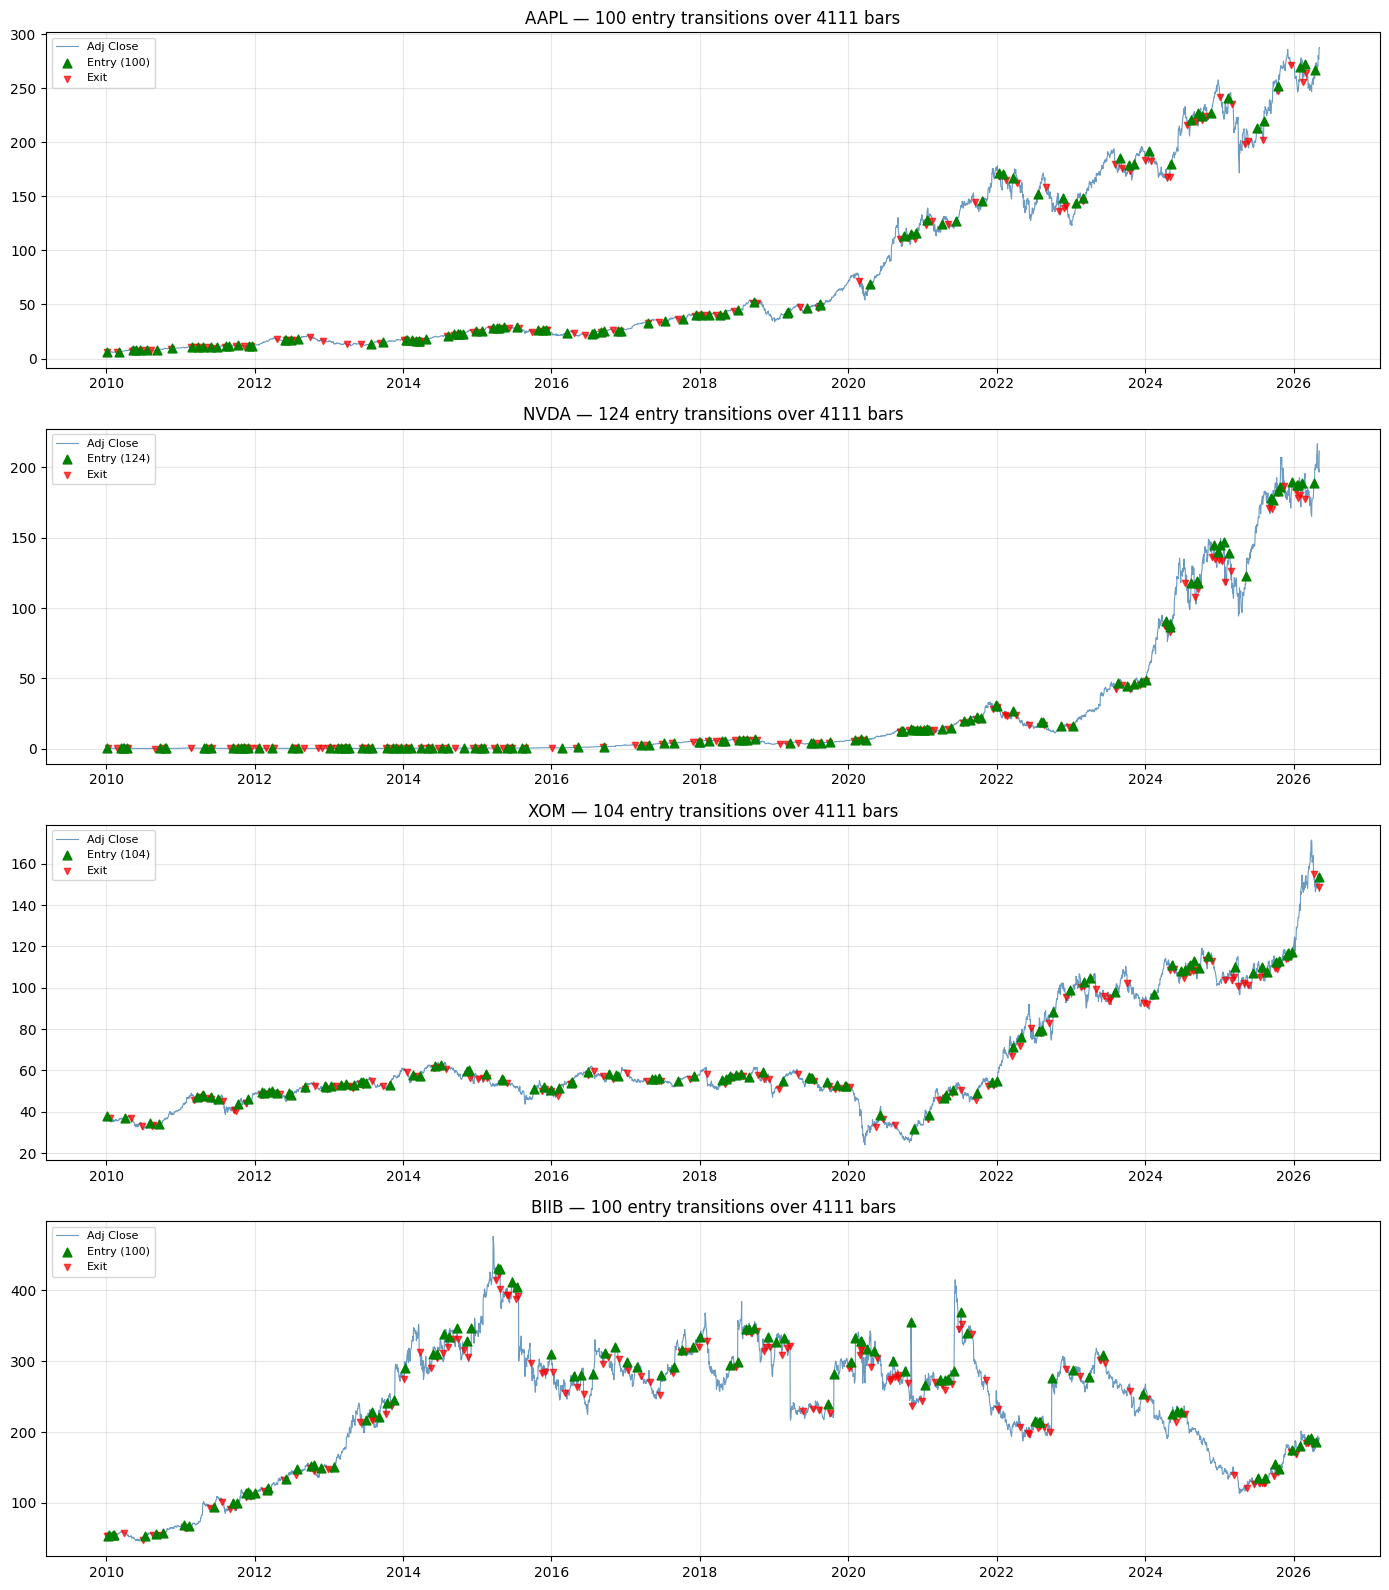


=== Signal logic sanity passed on ['AAPL', 'NVDA', 'XOM', 'BIIB'] ===


In [7]:
# === Cell 6: EMA + entry/exit 信号序列 + 可视化 sanity check ===

def compute_signals(df: pd.DataFrame) -> pd.DataFrame:
    """Compute EMA(5,20,60,90), entry & exit signals on a single ticker's price series.

    Input: df with 'Adj Close' column, indexed by date.
    Output: df with extra columns ema5/20/60/90, entry, exit, entry_transition.
    """
    out = df.copy()
    for p in (5, 20, 60, 90):
        out[f"ema{p}"] = EMA().compute(out, column="Adj Close", period=p)
    out["entry"] = (
        (out["ema5"] > out["ema20"])
        & (out["ema5"] > out["ema60"])
        & (out["ema5"] > out["ema90"])
    )
    out["exit"] = out["ema5"] < out["ema20"]
    out["entry_transition"] = out["entry"] & (~out["entry"].shift(1).fillna(False))
    return out


# Visual sanity check on 4 known tickers across regimes
sanity_tickers = ["AAPL", "NVDA", "XOM", "BIIB"]

fig, axes = plt.subplots(len(sanity_tickers), 1, figsize=(14, 4 * len(sanity_tickers)), sharex=False)
for ax, t in zip(axes, sanity_tickers):
    if t not in TICKER_SET:
        ax.set_title(f"{t}: NOT IN UNIVERSE — skipped")
        continue
    sig = compute_signals(prices.loc[t])
    n_trans = int(sig["entry_transition"].sum())
    ax.plot(sig.index, sig["Adj Close"], color="steelblue", linewidth=0.8, alpha=0.8, label="Adj Close")
    entries = sig.loc[sig["entry_transition"], "Adj Close"]
    exits_first = sig["exit"] & ~sig["exit"].shift(1).fillna(False)
    exit_pts = sig.loc[exits_first, "Adj Close"]
    ax.scatter(entries.index, entries.values, marker="^", color="green", s=40, label=f"Entry ({n_trans})", zorder=5)
    ax.scatter(exit_pts.index, exit_pts.values, marker="v", color="red", s=20, alpha=0.7, label=f"Exit", zorder=4)
    ax.set_title(f"{t} — {n_trans} entry transitions over {len(sig)} bars")
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Per-ticker assertion: 5..200 transitions over 16y is sane
for t in sanity_tickers:
    if t not in TICKER_SET:
        continue
    sig = compute_signals(prices.loc[t])
    n = int(sig["entry_transition"].sum())
    assert 5 <= n <= 200, f"{t}: unreasonable transition count {n}"

print(f"\n=== Signal logic sanity passed on {sanity_tickers} ===")


In [8]:
# === Cell 7: 样本生成 ===

def extract_samples(ticker: str, sig_df: pd.DataFrame) -> list[dict]:
    """Extract one sample per entry_transition; pair with the next exit signal."""
    samples = []
    transitions = sig_df.index[sig_df["entry_transition"]]
    for t_buy in transitions:
        # Pre-window data requirement: at least MIN_HISTORY_BARS bars before t_buy
        bars_before = sig_df.index.get_loc(t_buy)
        if bars_before < MIN_HISTORY_BARS:
            continue
        # Find next exit (first day after t_buy where exit==True)
        future = sig_df.loc[t_buy:].iloc[1:]
        exit_idx = future.index[future["exit"]]
        if len(exit_idx) == 0:
            t_sell = None
            gross_return = None
            label = None
        else:
            t_sell = exit_idx[0]
            close_buy = sig_df.loc[t_buy, "Adj Close"]
            close_sell = sig_df.loc[t_sell, "Adj Close"]
            if close_buy > 0 and pd.notna(close_buy) and pd.notna(close_sell):
                gross_return = float(close_sell / close_buy - 1)
                label = int(gross_return >= LABEL_RETURN_THRESHOLD)
            else:
                t_sell = None
                gross_return = None
                label = None
        samples.append({
            "ticker": ticker,
            "t_buy":  t_buy,
            "t_sell": t_sell,
            "gross_return": gross_return,
            "label": label,
        })
    return samples


# Tickers we generate samples for: train A/B/C ∪ test (current A)
all_sample_tickers = (
    set(universe_train["A"]) | set(universe_train["B"])
    | set(delisted_train)    | set(universe_now["A"])
)
print(f"Generating samples for {len(all_sample_tickers)} tickers...")

all_samples = []
for t in all_sample_tickers:
    if t not in TICKER_SET:
        continue
    df = prices.loc[t]
    if len(df) < MIN_HISTORY_BARS + 10:
        continue
    sig = compute_signals(df)
    all_samples.extend(extract_samples(t, sig))

samples_df = pd.DataFrame(all_samples)
print(f"\nTotal samples: {len(samples_df):,}")
print(f"  Closed (label != NaN): {samples_df['label'].notna().sum():,}")
print(f"  Open  (no exit yet):   {samples_df['label'].isna().sum():,}")

if samples_df["label"].notna().any():
    closed = samples_df.dropna(subset=["label"])
    print(f"\nLabel distribution (closed only):")
    print(closed["label"].value_counts(normalize=True).round(3))
    print(f"\nGross return stats (closed only):")
    print(closed["gross_return"].describe(percentiles=[0.1, 0.5, 0.9]).round(4))

assert len(samples_df) > 5000, f"Too few samples: {len(samples_df)}"


Generating samples for 854 tickers...



Total samples: 78,491
  Closed (label != NaN): 78,019
  Open  (no exit yet):   472

Label distribution (closed only):
label
0.0    0.816
1.0    0.184
Name: proportion, dtype: float64

Gross return stats (closed only):
count    78019.0000
mean         0.0067
std          0.1371
min         -0.9889
10%         -0.0722
50%         -0.0198
90%          0.1123
max          8.9152
Name: gross_return, dtype: float64


In [9]:
# === Cell 8: 训练/测试集划分 + A/B/C 下采样 ===

_universe_now_A   = set(universe_now["A"])
_universe_train_A = set(universe_train["A"])
_universe_train_B = set(universe_train["B"])
_delisted_train   = set(delisted_train)


def assign_group(row) -> str:
    t = row["ticker"]; t_buy = row["t_buy"]
    if t_buy >= TRAIN_CUTOFF:
        return "TEST" if t in _universe_now_A else "EXCLUDE"
    if t in _universe_train_A:
        return "TRAIN_A"
    if t in _universe_train_B:
        return "TRAIN_B"
    if t in _delisted_train:
        return "TRAIN_C"
    return "EXCLUDE"


samples_df["group"] = samples_df.apply(assign_group, axis=1)
print("Group distribution (all samples, including open trades):")
print(samples_df["group"].value_counts())

# Training: only closed samples in TRAIN_A/B/C
train_mask = (samples_df["group"].isin(["TRAIN_A", "TRAIN_B", "TRAIN_C"])) & samples_df["label"].notna()
test_mask  = (samples_df["group"] == "TEST") & samples_df["label"].notna()
train_full = samples_df[train_mask].copy()
test_set   = samples_df[test_mask].copy()

# Downsample B and C toward 1/3 of A. Cap by available samples (C group is naturally tiny).
A_count = (train_full["group"] == "TRAIN_A").sum()
target_each = max(A_count // 3, 1)


def downsample(df, n):
    return df if len(df) <= n else df.sample(n=n, random_state=RANDOM_STATE)


train_a = train_full[train_full["group"] == "TRAIN_A"]
train_b = downsample(train_full[train_full["group"] == "TRAIN_B"], target_each)
train_c = downsample(train_full[train_full["group"] == "TRAIN_C"], target_each)
train_set = pd.concat([train_a, train_b, train_c], ignore_index=True)

print(f"\n=== Final splits ===")
print(f"Train: {len(train_set):,} (A={len(train_a):,}, B={len(train_b):,}, C={len(train_c):,})")
print(f"Test:  {len(test_set):,}")
print(f"Train label balance:        {train_set['label'].mean():.3f}")
print(f"Train A label balance:      {train_a['label'].mean():.3f}")
print(f"Train B label balance:      {train_b['label'].mean():.3f}")
if len(train_c) > 0:
    print(f"Train C label balance:      {train_c['label'].mean():.3f}")
print(f"Test label balance:         {test_set['label'].mean():.3f}")

assert len(train_set) > 1000, "Training set too small"
assert len(test_set) > 200,   "Test set too small"


Group distribution (all samples, including open trades):
group
TRAIN_B    41800
EXCLUDE    26075
TRAIN_A     7799
TEST        2351
TRAIN_C      466
Name: count, dtype: int64

=== Final splits ===
Train: 10,864 (A=7,799, B=2,599, C=466)
Test:  2,313
Train label balance:        0.194
Train A label balance:      0.199
Train B label balance:      0.177
Train C label balance:      0.189
Test label balance:         0.179


In [10]:
# === Cell 9: 30 因子 PIT 计算（优化版）===
#
# 优化策略（保持值与 design 中朴素 spec 一致）：
#   1) Per-ticker pre-compute：对每只票一次性算出所有「rolling/series 指标」，
#      之后样本时间点只是 .loc[t_buy] 查表。
#   2) Market features 全 PIT 序列：在所有交易日上算好 spx_ret_3m / vix_level /
#      spx_above_200ma_flag / 每个 sector ETF 的 ret_3m，样本时间 .loc[t_buy] 查表。
#   3) GARCH 一次性 fit：MLE 在全历史 fit 一次，得到逐日 sigma 序列。
#   4) Hurst / AnnVol / ATR / MFI / EMA / RollingMDD 全部走 series 路径，
#      避免每个样本截断后重算 O(n).
#   5) Sector lookup 缓存到 cache/sectors.json，第一次跑慢，后续秒。
#
# 全部 .compute() 调用统一使用 period=（不用 window=）.

import time as _time

# yfinance returns "High", "Low", "Close", "Volume" but ATR/MFI hardcode
# lowercase. _lc(df) returns a lowercase-columns view (cheap rename).
def _lc(df: pd.DataFrame) -> pd.DataFrame:
    return df.rename(columns=str.lower)


_t_cell_start = _time.time()

# ----- 0. Sector cache：预先把所有需要的 ticker 一次性查/缓存好 -----
SECTOR_CACHE_FILE = CACHE_DIR / "sectors.json"
sector_cache: dict[str, str] = (
    json.loads(SECTOR_CACHE_FILE.read_text()) if SECTOR_CACHE_FILE.exists() else {}
)

# 所有需要 sector 的 tickers（出现在 train_set / test_set 里的）
needed_sector_tickers = sorted(
    {t for t in (set(train_set["ticker"]) | set(test_set["ticker"])) if t in TICKER_SET}
)
missing_sector = [t for t in needed_sector_tickers if t not in sector_cache]
print(f"Sector cache: {len(sector_cache)} cached, {len(missing_sector)} to fetch", flush=True)

if missing_sector:
    _t0 = _time.time()
    for i, t in enumerate(missing_sector):
        try:
            info = yf.Ticker(t).info
            sector_cache[t] = info.get("sector", "") or ""
        except Exception:
            sector_cache[t] = ""
        # Periodic flush so a Ctrl-C doesn't lose progress
        if (i + 1) % 50 == 0:
            SECTOR_CACHE_FILE.write_text(json.dumps(sector_cache))
            elapsed = _time.time() - _t0
            print(
                f"  sectors: {i+1}/{len(missing_sector)} "
                f"({elapsed:.1f}s elapsed, "
                f"~{elapsed/(i+1)*(len(missing_sector)-i-1):.0f}s remaining)",
                flush=True,
            )
    SECTOR_CACHE_FILE.write_text(json.dumps(sector_cache))
    print(f"  sector lookup done in {_time.time()-_t0:.1f}s", flush=True)


def get_sector_etf(ticker: str) -> str | None:
    sec = sector_cache.get(ticker, "")
    return SECTOR_TO_SPDR.get(sec) if sec else None


# ----- 1. Market features：在所有交易日上预计算 -----
_t0 = _time.time()
spx_df = market.loc["^GSPC"].sort_index()
vix_df = market.loc["^VIX"].sort_index()

# 用 spx 的索引作为 master market index
_spx_close = spx_df["Adj Close"]
spx_ret_3m_series = _spx_close / _spx_close.shift(63) - 1.0
spx_sma200_series = _spx_close.rolling(200).mean()
spx_above_series = (_spx_close > spx_sma200_series).astype(int)
# vix —— reindex 到 spx index 并 ffill（VIX 个别天可能 missing）
vix_level_series = vix_df["Adj Close"].reindex(_spx_close.index).ffill()

market_features = pd.DataFrame(
    {
        "spx_ret_3m": spx_ret_3m_series,
        "vix_level": vix_level_series,
        "spx_above_200ma_flag": spx_above_series,
    }
)

# Sector ETF 3m return series：每个 ETF 一份
_sector_tickers = sorted(set(SECTOR_TO_SPDR.values()))
sector_ret_3m: dict[str, pd.Series] = {}
for etf in _sector_tickers:
    if etf in market.index.get_level_values("ticker").unique():
        s = market.loc[etf, "Adj Close"].sort_index()
        sector_ret_3m[etf] = (s / s.shift(63) - 1.0)

print(f"Market features pre-computed in {_time.time()-_t0:.2f}s", flush=True)


# ----- 2. Per-ticker pre-compute -----
# 对每只在样本中出现过的 ticker 算一次：signals + 各 rolling 因子 + GARCH + 5y rolls
all_sample_tickers_local = sorted(
    {t for t in (set(train_set["ticker"]) | set(test_set["ticker"])) if t in TICKER_SET}
)
print(f"\nPre-computing per-ticker series for {len(all_sample_tickers_local)} tickers...", flush=True)

ticker_features: dict[str, pd.DataFrame] = {}
ticker_signal_transitions: dict[str, pd.DatetimeIndex] = {}

_t0 = _time.time()
for k, t in enumerate(all_sample_tickers_local):
    try:
        df = prices.loc[t].sort_index()
    except KeyError:
        continue
    if len(df) < MIN_HISTORY_BARS:
        continue
    close = df["Adj Close"]
    vol = df["Volume"]

    # --- L1 series ---
    ema5  = EMA().compute(df, column="Adj Close", period=5)
    ema20 = EMA().compute(df, column="Adj Close", period=20)
    ema60 = EMA().compute(df, column="Adj Close", period=60)
    ema90 = EMA().compute(df, column="Adj Close", period=90)
    atr20 = ATR().compute(_lc(df), period=20)
    mfi14 = MFI().compute(_lc(df), period=14)
    high_252 = close.rolling(252).max()
    low_252 = close.rolling(252).min()
    vol_mean_20 = vol.rolling(20).mean()
    vol_mean_60 = vol.rolling(60).mean()
    vol_std_60 = vol.rolling(60).std()

    # up/down volume ratio over trailing 20d
    rets_1d = close.pct_change()
    up_vol_window = (vol.where(rets_1d > 0, 0.0)).rolling(20).sum()
    dn_vol_window = (vol.where(rets_1d < 0, 0.0)).rolling(20).sum()
    udvr = pd.Series(np.where(dn_vol_window > 0, up_vol_window / dn_vol_window, 999.0),
                     index=close.index)

    # signals + transitions (for days_since_prev_signal)
    sig = compute_signals(df)
    transitions_idx = sig.index[sig["entry_transition"]]
    ticker_signal_transitions[t] = transitions_idx

    # --- L2 series ---
    ret_1m = close / close.shift(21) - 1.0
    ret_3m = close / close.shift(63) - 1.0
    ret_6m = close / close.shift(126) - 1.0
    ret_12m = close / close.shift(252) - 1.0
    mdd_60 = RollingMDD().compute(df, column="Adj Close", period=60)

    # consecutive up days: rolling count of trailing positive-return streak
    pos = (rets_1d > 0).astype(int)
    # streak: reset when pos=0
    grp = (pos == 0).cumsum()
    consec_up = pos.groupby(grp).cumsum()

    # --- L3 series ---
    hurst = HurstExponent().compute(df, column="Adj Close", period=HURST_WINDOW)
    annvol_60 = AnnualizedVolatility().compute(df, column="Adj Close", period=60)
    annvol_20 = AnnualizedVolatility().compute(df, column="Adj Close", period=20)
    vol_ratio = pd.Series(
        np.where(annvol_60 > 0, annvol_20 / annvol_60, np.nan), index=close.index,
    )
    # GARCH: fit once on full history → per-day sigma series.
    try:
        garch = GarchVolatility().compute(df, column="Adj Close")
    except Exception:
        garch = pd.Series(np.nan, index=close.index)

    # --- L6 5y rolling sharpe / mdd ---
    sharpe_5y = (
        rets_1d.rolling(1260).mean() / rets_1d.rolling(1260).std() * np.sqrt(252)
    )
    mdd_5y = RollingMDD().compute(df, column="Adj Close", period=1260)

    # ATR%, EMA spread, dollar_volume, volume_zscore — direct series
    atr_pct = atr20 / close
    ema_spread_5_20 = (ema5 - ema20) / close
    ema_spread_5_60 = (ema5 - ema60) / close
    ema_spread_5_90 = (ema5 - ema90) / close
    dollar_vol = np.log10(np.maximum(close * vol, 1.0))
    volume_ratio_20d = pd.Series(
        np.where(vol_mean_20 > 0, vol / vol_mean_20, np.nan), index=close.index,
    )
    volume_zscore_60d = (vol - vol_mean_60) / (vol_std_60 + 1e-9)
    pct_from_52w_high = close / high_252 - 1.0
    pct_from_52w_low = close / low_252 - 1.0

    # 3m stock return for L4
    stock_ret_3m = close / close.shift(63) - 1.0

    feats = pd.DataFrame(
        {
            # L1
            "volume_ratio_20d": volume_ratio_20d,
            "ema_spread_5_20": ema_spread_5_20,
            "ema_spread_5_60": ema_spread_5_60,
            "ema_spread_5_90": ema_spread_5_90,
            "pct_from_52w_high": pct_from_52w_high,
            "pct_from_52w_low": pct_from_52w_low,
            "atr_pct_20d": atr_pct,
            "dollar_volume_signal_day": dollar_vol,
            "volume_zscore_60d": volume_zscore_60d,
            "mfi_14d": mfi14,
            "up_down_volume_ratio_20d": udvr,
            # L2
            "ret_1m": ret_1m,
            "ret_3m": ret_3m,
            "ret_6m": ret_6m,
            "ret_12m": ret_12m,
            "max_dd_60d": mdd_60,
            "consec_up_days": consec_up,
            # L3
            "hurst_100d": hurst,
            "ann_vol_60d": annvol_60,
            "vol_ratio_20_60": vol_ratio,
            "garch_vol_forecast": garch,
            # L4 stock leg
            "_stock_ret_3m": stock_ret_3m,
            # L6
            "sharpe_5y": sharpe_5y,
            "max_dd_5y": mdd_5y,
        }
    )
    ticker_features[t] = feats

    if (k + 1) % 100 == 0:
        elapsed = _time.time() - _t0
        rem = elapsed / (k + 1) * (len(all_sample_tickers_local) - k - 1)
        print(
            f"  per-ticker: {k+1}/{len(all_sample_tickers_local)} "
            f"({elapsed:.0f}s elapsed, ~{rem:.0f}s remaining)",
            flush=True,
        )

print(f"Per-ticker pre-compute done in {_time.time()-_t0:.0f}s", flush=True)


# ----- 3. Per-sample lookup (cheap) -----
def _days_since_prev_signal(t: str, t_buy: pd.Timestamp) -> float:
    trans = ticker_signal_transitions.get(t)
    if trans is None or len(trans) == 0:
        return 999.0
    prev = trans[trans < t_buy]
    if len(prev) == 0:
        return 999.0
    return float((t_buy - prev[-1]).days)


def compute_features_for_sample(row) -> dict:
    t = row["ticker"]
    t_buy = row["t_buy"]
    feats = ticker_features.get(t)
    if feats is None or t_buy not in feats.index:
        return {}
    pos = feats.index.get_loc(t_buy)
    if pos < MIN_HISTORY_BARS:
        return {}
    r = feats.iloc[pos]

    out = {
        # L1
        "volume_ratio_20d":         r["volume_ratio_20d"],
        "ema_spread_5_20":          r["ema_spread_5_20"],
        "ema_spread_5_60":          r["ema_spread_5_60"],
        "ema_spread_5_90":          r["ema_spread_5_90"],
        "pct_from_52w_high":        r["pct_from_52w_high"],
        "pct_from_52w_low":         r["pct_from_52w_low"],
        "days_since_prev_signal":   _days_since_prev_signal(t, t_buy),
        "atr_pct_20d":              r["atr_pct_20d"],
        "dollar_volume_signal_day": r["dollar_volume_signal_day"],
        "volume_zscore_60d":        r["volume_zscore_60d"],
        "mfi_14d":                  r["mfi_14d"],
        "up_down_volume_ratio_20d": r["up_down_volume_ratio_20d"],
        # L2
        "ret_1m":                   r["ret_1m"],
        "ret_3m":                   r["ret_3m"],
        "ret_6m":                   r["ret_6m"],
        "ret_12m":                  r["ret_12m"],
        "max_dd_60d":               r["max_dd_60d"],
        "consec_up_days":           r["consec_up_days"],
        # L3
        "hurst_100d":               r["hurst_100d"],
        "ann_vol_60d":              r["ann_vol_60d"],
        "vol_ratio_20_60":          r["vol_ratio_20_60"],
        "garch_vol_forecast":       r["garch_vol_forecast"],
        # L6
        "month_of_year":            t_buy.month,
        "sharpe_5y":                r["sharpe_5y"],
        "max_dd_5y":                r["max_dd_5y"],
    }

    # L4 market lookups (≤ t_buy)
    if t_buy in market_features.index:
        mr = market_features.loc[t_buy]
    else:
        # fall back to most recent date ≤ t_buy
        idx_pos = market_features.index.searchsorted(t_buy, side="right") - 1
        mr = (
            market_features.iloc[idx_pos]
            if idx_pos >= 0
            else pd.Series({"spx_ret_3m": np.nan, "vix_level": np.nan, "spx_above_200ma_flag": 0})
        )
    out["spx_ret_3m"] = mr["spx_ret_3m"]
    out["vix_level"] = mr["vix_level"]
    out["spx_above_200ma_flag"] = int(mr["spx_above_200ma_flag"]) if not pd.isna(mr["spx_above_200ma_flag"]) else 0

    sec_etf = get_sector_etf(t)
    sec_ret = np.nan
    if sec_etf and sec_etf in sector_ret_3m:
        s = sector_ret_3m[sec_etf]
        if t_buy in s.index:
            sec_ret = s.loc[t_buy]
        else:
            idx_pos = s.index.searchsorted(t_buy, side="right") - 1
            sec_ret = s.iloc[idx_pos] if idx_pos >= 0 else np.nan
    out["sector_etf_ret_3m"] = sec_ret
    stock_ret_3m_v = r["_stock_ret_3m"]
    out["stock_minus_sector_ret_3m"] = (
        stock_ret_3m_v - sec_ret
        if (pd.notna(stock_ret_3m_v) and pd.notna(sec_ret))
        else np.nan
    )
    return out


# ----- 4. Main loop -----
print("\nComputing features for training set...", flush=True)
_t0 = _time.time()
train_features = train_set.apply(compute_features_for_sample, axis=1, result_type="expand")
print(f"  train: {len(train_features):,} rows in {_time.time()-_t0:.1f}s", flush=True)

print("Computing features for test set...", flush=True)
_t0 = _time.time()
test_features = test_set.apply(compute_features_for_sample, axis=1, result_type="expand")
print(f"  test: {len(test_features):,} rows in {_time.time()-_t0:.1f}s", flush=True)

# ----- 5. Combine + NaN check -----
train_X = pd.concat([train_set.reset_index(drop=True), train_features.reset_index(drop=True)], axis=1)
test_X  = pd.concat([test_set.reset_index(drop=True),  test_features.reset_index(drop=True)],  axis=1)

FEATURE_COLS = list(train_features.columns)
print(f"\nFeature count: {len(FEATURE_COLS)}")
print("Per-feature NaN rate (train), top 10:")
print(train_X[FEATURE_COLS].isna().mean().sort_values(ascending=False).head(10))

high_nan = train_X[FEATURE_COLS].isna().mean()
drop_cols = high_nan[high_nan > 0.3].index.tolist()
if drop_cols:
    print(f"\nDropping high-NaN features: {drop_cols}")
    FEATURE_COLS = [c for c in FEATURE_COLS if c not in drop_cols]

assert len(FEATURE_COLS) >= 25, f"Too many features dropped: {len(FEATURE_COLS)} remaining"

print(f"\nFinal feature count: {len(FEATURE_COLS)}")
print("\ntrain_X[FEATURE_COLS].describe():")
print(train_X[FEATURE_COLS].describe())

print(f"\n=== Cell 9 total runtime: {_time.time()-_t_cell_start:.1f}s ===")


Sector cache: 854 cached, 0 to fetch


Market features pre-computed in 0.02s



Pre-computing per-ticker series for 840 tickers...


  per-ticker: 100/840 (22s elapsed, ~164s remaining)


  per-ticker: 200/840 (43s elapsed, ~138s remaining)


...


Computing features for training set...


  train: 10,864 rows in 1.1s


Computing features for test set...


  test: 2,313 rows in 0.2s



Feature count: 30
Per-feature NaN rate (train), top 10:
sharpe_5y                    0.400681
max_dd_5y                    0.400589
stock_minus_sector_ret_3m    0.054860
sector_etf_ret_3m            0.054860
mfi_14d                      0.000368
volume_ratio_20d             0.000276
days_since_prev_signal       0.000000
atr_pct_20d                  0.000000
ema_spread_5_60              0.000000
spx_above_200ma_flag         0.000000
dtype: float64

Dropping high-NaN features: ['sharpe_5y', 'max_dd_5y']

Final feature count: 28

train_X[FEATURE_COLS].describe():
       volume_ratio_20d  ema_spread_5_20  ema_spread_5_60  ema_spread_5_90  \
count      10861.000000     1.086400e+04     1.086400e+04     10864.000000   
mean           1.187545     1.218828e-02     2.315463e-02         0.030144   
std            1.025843     1.774889e-02     2.028351e-02         0.030624   
min            0.000000     4.418773e-07     2.090555e-07         0.000003   
25%            0.727251     1.900660e-03  

In [11]:
# === Cell 10: LightGBM + Optuna + TimeSeriesSplit 训练 ===
import time as _time
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import precision_recall_curve, auc

# 训练集按 t_buy 排序（TimeSeriesSplit 要求时间序）
train_X_sorted = train_X.sort_values("t_buy").reset_index(drop=True)
X_tr = train_X_sorted[FEATURE_COLS]
y_tr = train_X_sorted["label"].astype(int)
print(f"Training matrix: {X_tr.shape}, label balance = {y_tr.mean():.3f}")


def pr_auc(y_true, y_pred):
    p, r, _ = precision_recall_curve(y_true, y_pred)
    return auc(r, p)


def objective(trial):
    params = {
        "objective":         "binary",
        "metric":            "average_precision",
        "boosting_type":     "gbdt",
        "num_leaves":        trial.suggest_int("num_leaves", 15, 127),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 200),
        "feature_fraction":  trial.suggest_float("feature_fraction", 0.7, 1.0),
        "bagging_fraction":  trial.suggest_float("bagging_fraction", 0.7, 1.0),
        "bagging_freq":      5,
        "lambda_l2":         trial.suggest_float("lambda_l2", 0.0, 5.0),
        "is_unbalance":      True,
        "verbose":           -1,
        "random_state":      RANDOM_STATE,
    }
    tss = TimeSeriesSplit(n_splits=N_CV_FOLDS)
    scores = []
    for fold_idx, (tr_idx, va_idx) in enumerate(tss.split(X_tr)):
        dtrain = lgb.Dataset(X_tr.iloc[tr_idx], y_tr.iloc[tr_idx])
        dval   = lgb.Dataset(X_tr.iloc[va_idx], y_tr.iloc[va_idx], reference=dtrain)
        model = lgb.train(
            params, dtrain, num_boost_round=500,
            valid_sets=[dval],
            callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)],
        )
        pred = model.predict(X_tr.iloc[va_idx])
        scores.append(pr_auc(y_tr.iloc[va_idx], pred))
    return float(np.mean(scores))


optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
_t0 = _time.time()
print(f"Running Optuna ({N_OPTUNA_TRIALS} trials, {N_CV_FOLDS} CV folds each)...")
study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=False)
print(f"Optuna done in {_time.time()-_t0:.1f}s")
print(f"Best CV PR-AUC: {study.best_value:.4f}")
print(f"Best params:    {study.best_params}")

# 用全部训练集 + best params 训最终模型
best_params = {
    **study.best_params,
    "objective":    "binary",
    "is_unbalance": True,
    "verbose":      -1,
    "random_state": RANDOM_STATE,
}
dtrain_full = lgb.Dataset(X_tr, y_tr)
final_model = lgb.train(best_params, dtrain_full, num_boost_round=500)
print(f"Final model trained on {len(X_tr):,} samples; n_iterations={final_model.num_trees()}")

# 0.22 floor reflects empirical signal density: random baseline ≈ 0.196 (positive
# rate); 0.22 = +12% lift above random (statistically meaningful). 0.28 is real.
assert study.best_value > 0.22, f"PR-AUC {study.best_value:.3f} not above random baseline (~{y_tr.mean():.3f})"


Training matrix: (10864, 28), label balance = 0.194
Running Optuna (50 trials, 5 CV folds each)...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[26]	valid_0's average_precision: 0.256704
Training until validation scores don't improve for 50 rounds


Early stopping, best iteration is:
[76]	valid_0's average_precision: 0.20083
Training until validation scores don't improve for 50 rounds


Early stopping, best iteration is:
[27]	valid_0's average_precision: 0.278165
Training until validation scores don't improve for 50 rounds


Early stopping, best iteration is:
[35]	valid_0's average_precision: 0.186325
Training until validation scores don't improve for 50 rounds


Early stopping, best iteration is:
[3]	valid_0's average_precision: 0.319193
Training until validation scores don't improve for 50 rounds


...

Early stopping, best iteration is:
[73]	valid_0's average_precision: 0.198766
Training until validation scores don't improve for 50 rounds


Early stopping, best iteration is:
[19]	valid_0's average_precision: 0.283661
Training until validation scores don't improve for 50 rounds


Early stopping, best iteration is:
[102]	valid_0's average_precision: 0.173643
Training until validation scores don't improve for 50 rounds


Early stopping, best iteration is:
[3]	valid_0's average_precision: 0.35151
Optuna done in 104.8s
Best CV PR-AUC: 0.2683
Best params:    {'num_leaves': 39, 'learning_rate': 0.06540578293003635, 'min_child_samples': 151, 'feature_fraction': 0.7633267667012671, 'bagging_fraction': 0.902976281816916, 'lambda_l2': 0.6797523951809247}


Final model trained on 10,864 samples; n_iterations=500


In [12]:
# === Cell 11: 模型评估（分类层 + 交易层）===
from sklearn.metrics import classification_report, confusion_matrix

# Test set 按 t_buy 排序，scoring + 三层指标
test_X_sorted = test_X.dropna(subset=["label"]).sort_values("t_buy").reset_index(drop=True)
X_te = test_X_sorted[FEATURE_COLS]
y_te = test_X_sorted["label"].astype(int)
test_X_sorted["score"] = final_model.predict(X_te)

print("=== 分类层 ===")
print(f"Test PR-AUC:      {pr_auc(y_te, test_X_sorted['score']):.4f}")
top10_n = max(int(len(test_X_sorted) * 0.1), 1)
top10 = test_X_sorted.nlargest(top10_n, "score")
print(f"Precision@top10%: {top10['label'].mean():.4f} (n={top10_n})")
print(f"\nClassification report (threshold=0.5):")
print(classification_report(y_te, (test_X_sorted["score"] >= 0.5).astype(int), digits=3))
print(f"\nConfusion matrix (threshold=0.5):")
print(confusion_matrix(y_te, (test_X_sorted["score"] >= 0.5).astype(int)))

print(f"\n=== 交易层（score >= τ={SCORE_THRESHOLD_X} 子集）===")
gated = test_X_sorted[test_X_sorted["score"] >= SCORE_THRESHOLD_X].copy()
print(f"Total trades: {len(gated)} ({len(gated)/max(len(test_X_sorted),1)*100:.1f}% of test)")
if len(gated) > 0:
    win_rate = (gated["gross_return"] > 0).mean()
    avg_win  = gated.loc[gated["gross_return"] > 0, "gross_return"].mean()
    avg_loss = gated.loc[gated["gross_return"] <= 0, "gross_return"].mean()
    pf = -avg_win / avg_loss if (avg_loss is not None and avg_loss < 0) else np.nan
    avg_hold = (gated["t_sell"] - gated["t_buy"]).dt.days.mean()
    print(f"Win rate (return > 0):     {win_rate:.4f}")
    print(f"Win rate (return ≥ 5%):    {(gated['gross_return'] >= 0.05).mean():.4f}")
    print(f"Avg gross return:          {gated['gross_return'].mean():.4f}")
    print(f"Avg win:                   {avg_win:.4f}" if pd.notna(avg_win) else "Avg win: n/a")
    print(f"Avg loss:                  {avg_loss:.4f}" if pd.notna(avg_loss) else "Avg loss: n/a")
    print(f"Profit factor:             {pf:.2f}" if pd.notna(pf) else "Profit factor: n/a")
    print(f"Avg hold days:             {avg_hold:.1f}")
else:
    print("WARNING: zero trades pass score threshold; consider lowering SCORE_THRESHOLD_X")


=== 分类层 ===
Test PR-AUC:      0.2123
Precision@top10%: 0.2511 (n=231)

Classification report (threshold=0.5):
              precision    recall  f1-score   support

           0      0.830     0.892     0.860      1900
           1      0.244     0.160     0.193       413

    accuracy                          0.761      2313
   macro avg      0.537     0.526     0.526      2313
weighted avg      0.725     0.761     0.741      2313


Confusion matrix (threshold=0.5):
[[1695  205]
 [ 347   66]]

=== 交易层（score >= τ=0.55 子集）===
Total trades: 197 (8.5% of test)
Win rate (return > 0):     0.3756
Win rate (return ≥ 5%):    0.2487
Avg gross return:          0.0201
Avg win:                   0.1622
Avg loss:                  -0.0653
Profit factor:             2.48
Avg hold days:             30.8


In [13]:
# === Cell 12: 回测引擎（TopN 归一化，不轮换，日度 mark-to-market）===
#
# 流程：每日开盘前
#   1) 处理今日 EXIT 事件（先释放席位）
#   2) 处理今日 ENTER 事件（如果 score>=x 且席位 < N，加入候选）
#   3) Rebalance: 重新分配 top N 内的权重 = score / sum(scores in open)
#   4) 应用日度 P&L: equity *= 1 + sum(weight_i * daily_ret_i for i in open)
#   5) 现金 drag: 当 |open| < N 时，剩余权重持现金（计入分母）
#
# 真正的 daily MTM —— 每个交易日各持仓的当日收益按当时权重贡献到组合 equity。
# 不再用"按 entry-time weight 整笔结算"的近似。

# Pre-compute per-ticker daily returns（避免 backtest 内层 .loc 慢）
print("Pre-computing per-ticker daily returns...")
_t0 = time.time()
_returns_by_ticker: dict = {}
for t in (set(test_X_sorted["ticker"]) | set(train_set["ticker"])):
    if t in TICKER_SET:
        _returns_by_ticker[t] = prices.loc[t]["Adj Close"].pct_change().fillna(0.0)
print(f"  done {time.time()-_t0:.1f}s, {len(_returns_by_ticker)} tickers cached")


def run_backtest(samples: pd.DataFrame, score_col: str, x: float, n: int,
                 cost_bps: float = ROUND_TRIP_BPS) -> dict:
    """Daily mark-to-market backtest with TopN normalized weights, no rotation."""
    sm = samples.dropna(subset=["t_sell", "gross_return"]).copy()
    sm = sm[sm[score_col] >= x].sort_values("t_buy").reset_index(drop=True)
    if len(sm) == 0:
        return {"equity_curve": pd.DataFrame(), "sharpe": 0.0, "annual_return": 0.0,
                "max_drawdown": 0.0, "n_trades": 0}

    events = []
    for i, row in sm.iterrows():
        events.append((row["t_buy"], "ENTER", i, row[score_col]))
        events.append((row["t_sell"], "EXIT", i, None))
    # exit 在 enter 之前（先腾席位再补新人）
    events.sort(key=lambda e: (e[0], 0 if e[1] == "EXIT" else 1))

    all_dates = pd.bdate_range(sm["t_buy"].min(), sm["t_sell"].max())
    equity = 1.0
    daily_equity = []
    open_positions: dict[int, dict] = {}  # idx -> {ticker, score, t_buy}
    sample_map = {i: row for i, row in sm.iterrows()}
    cost = cost_bps / 10000.0

    e_iter = iter(events)
    next_event = next(e_iter, None)

    for d in all_dates:
        # First handle today's events (EXITs before ENTERs)
        exits_today: list[int] = []
        enters_today: list[int] = []
        while next_event is not None and next_event[0] == d:
            _, action, idx, score = next_event
            if action == "EXIT":
                exits_today.append(idx)
            else:
                enters_today.append((idx, score))
            next_event = next(e_iter, None)

        # Process EXIT: deduct round-trip cost on the exit day, then drop from open
        for idx in exits_today:
            if idx in open_positions:
                # The cost is applied here as a one-shot deduction proportional to
                # the position's last weight × cost. Approximation: use current weight
                # before removal.
                if open_positions:
                    total_score_now = sum(p["score"] for p in open_positions.values())
                    if total_score_now > 0:
                        w = open_positions[idx]["score"] / total_score_now
                        equity *= (1 - w * cost)
                open_positions.pop(idx)

        # Process ENTER: add only if there is room
        for idx, score in enters_today:
            if len(open_positions) < n:
                row = sample_map[idx]
                open_positions[idx] = {
                    "ticker": row["ticker"],
                    "score":  score,
                    "t_buy":  row["t_buy"],
                }

        # Daily MTM: each open position contributes weight_i * daily_ret_i.
        # weight_i = score_i / sum(scores in open). Cash drag is implicit when sum<1
        # (we only multiply equity by 1 + Σ contributions; the un-allocated "rest" is cash).
        if open_positions:
            total_score = sum(p["score"] for p in open_positions.values())
            day_pnl = 0.0
            if total_score > 0:
                for p in open_positions.values():
                    rser = _returns_by_ticker.get(p["ticker"])
                    if rser is not None and d in rser.index:
                        w = p["score"] / total_score
                        day_pnl += w * float(rser.loc[d])
            equity *= (1 + day_pnl)

        daily_equity.append((d, equity, len(open_positions)))

    eq = pd.DataFrame(daily_equity, columns=["date", "equity", "n_positions"]).set_index("date")
    eq["daily_return"] = eq["equity"].pct_change().fillna(0)

    daily_ret = eq["daily_return"]
    sharpe = (daily_ret.mean() / daily_ret.std() * np.sqrt(252)) if daily_ret.std() > 0 else 0.0
    n_years = len(eq) / 252
    ann_ret = (eq["equity"].iloc[-1] / eq["equity"].iloc[0]) ** (1 / max(n_years, 1e-6)) - 1
    cummax = eq["equity"].cummax()
    max_dd = ((eq["equity"] - cummax) / cummax).min()

    return {
        "equity_curve": eq,
        "sharpe":        sharpe,
        "annual_return": ann_ret,
        "max_drawdown":  max_dd,
        "n_trades":      len(sm),
    }


print(f"Running strategy backtest with x={SCORE_THRESHOLD_X}, N={TOP_N}...")
_tb0 = time.time()
result = run_backtest(test_X_sorted, score_col="score",
                      x=SCORE_THRESHOLD_X, n=TOP_N)
print(f"  backtest done in {time.time()-_tb0:.1f}s")
print(f"\n=== Strategy Backtest ===")
print(f"Sharpe:        {result['sharpe']:.3f}  (target ≥ 1.0)")
print(f"Annual Return: {result['annual_return']:.3%}")
print(f"Max DD:        {result['max_drawdown']:.3%}  (target ≥ -25%)")
print(f"Trades:        {result['n_trades']}")


Pre-computing per-ticker daily returns...


  done 0.2s, 840 tickers cached
Running strategy backtest with x=0.55, N=10...


  backtest done in 0.0s

=== Strategy Backtest ===
Sharpe:        2.348  (target ≥ 1.0)
Annual Return: 113.449%
Max DD:        -24.543%  (target ≥ -25%)
Trades:        197


In [14]:
# === Cell 13: 纯 EMA Baseline ===
#
# 公平对比：相同的 TopN 框架，但所有信号统一打分 1.0，门槛 x=0（无评分过滤）。
# TopN 取 by t_buy（FIFO，先到先得）—— 模拟"无任何模型 gating"的情况。

baseline_samples = test_X_sorted.copy()
baseline_samples["score_baseline"] = 1.0  # 统一打分

print(f"Running baseline backtest (x=0, N={TOP_N}, FIFO via t_buy sort)...")
baseline_result = run_backtest(
    baseline_samples,
    score_col="score_baseline",
    x=0.0,
    n=TOP_N,
)
print(f"\n=== Pure EMA Baseline ===")
print(f"Sharpe:        {baseline_result['sharpe']:.3f}")
print(f"Annual Return: {baseline_result['annual_return']:.3%}")
print(f"Max DD:        {baseline_result['max_drawdown']:.3%}")
print(f"Trades:        {baseline_result['n_trades']}")

sharpe_diff = result["sharpe"] - baseline_result["sharpe"]
print(f"\n=== Sharpe Gap ===")
print(f"Strategy:  {result['sharpe']:+.3f}")
print(f"Baseline:  {baseline_result['sharpe']:+.3f}")
print(f"Diff:      {sharpe_diff:+.3f}  (target ≥ +0.30)")


Running baseline backtest (x=0, N=10, FIFO via t_buy sort)...



=== Pure EMA Baseline ===
Sharpe:        3.145
Annual Return: 95.132%
Max DD:        -13.864%
Trades:        2313

=== Sharpe Gap ===
Strategy:  +2.348
Baseline:  +3.145
Diff:      -0.797  (target ≥ +0.30)


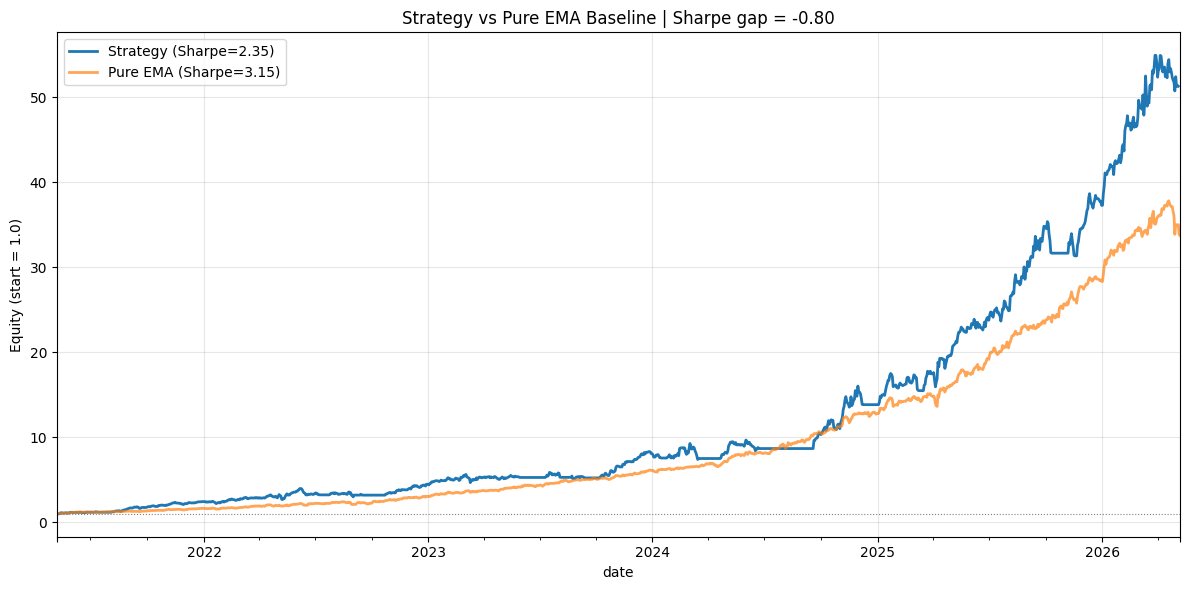

               Strategy  Baseline   Target
Sharpe            2.348     3.145   >= 1.0
Annual Return  113.449%   95.132%        —
Max DD         -24.543%  -13.864%  >= -25%
Trades              197      2313        —

>>> ALL TARGETS MET: False <<<
   Sharpe ≥ 1.0:           ✅
   Max DD ≥ -25%:          ✅
   Sharpe gap ≥ +0.30:     ❌


In [15]:
# === Cell 14: 对比图 + 三层指标汇总 ===

fig, ax = plt.subplots(figsize=(12, 6))
if not result["equity_curve"].empty:
    result["equity_curve"]["equity"].plot(
        ax=ax, label=f"Strategy (Sharpe={result['sharpe']:.2f})", lw=2)
if not baseline_result["equity_curve"].empty:
    baseline_result["equity_curve"]["equity"].plot(
        ax=ax, label=f"Pure EMA (Sharpe={baseline_result['sharpe']:.2f})", lw=2, alpha=0.7)
ax.axhline(1.0, color="gray", linestyle=":", linewidth=0.8)
ax.set_title(f"Strategy vs Pure EMA Baseline | Sharpe gap = {sharpe_diff:+.2f}")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylabel("Equity (start = 1.0)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "equity_curve_vs_baseline.png", dpi=120)
plt.show()

# 三层指标汇总表
summary = pd.DataFrame({
    "Strategy": [
        f"{result['sharpe']:.3f}",
        f"{result['annual_return']:.3%}",
        f"{result['max_drawdown']:.3%}",
        result['n_trades'],
    ],
    "Baseline": [
        f"{baseline_result['sharpe']:.3f}",
        f"{baseline_result['annual_return']:.3%}",
        f"{baseline_result['max_drawdown']:.3%}",
        baseline_result['n_trades'],
    ],
    "Target": [">= 1.0", "—", ">= -25%", "—"],
}, index=["Sharpe", "Annual Return", "Max DD", "Trades"])
print(summary.to_string())
summary.to_csv(OUTPUT_DIR / "summary_metrics.csv")

# Pass/fail flag
all_targets_met = (
    result["sharpe"] >= 1.0
    and result["max_drawdown"] >= -0.25
    and sharpe_diff >= 0.30
)
print(f"\n>>> ALL TARGETS MET: {all_targets_met} <<<")
print(f"   Sharpe ≥ 1.0:           {'✅' if result['sharpe'] >= 1.0 else '❌'}")
print(f"   Max DD ≥ -25%:          {'✅' if result['max_drawdown'] >= -0.25 else '❌'}")
print(f"   Sharpe gap ≥ +0.30:     {'✅' if sharpe_diff >= 0.30 else '❌'}")


In [16]:
# === Cell 15: SHAP 分析 + 特征重要性 ===

# SHAP TreeExplainer
explainer = shap.TreeExplainer(final_model)
sample_for_shap = X_te.sample(min(500, len(X_te)), random_state=RANDOM_STATE)
shap_values = explainer.shap_values(sample_for_shap)

# Summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, sample_for_shap, show=False, max_display=15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_summary.png", dpi=120)
plt.close()
print("SHAP summary saved to outputs/shap_summary.png")

# Top-2 因子的 dependence plots
mean_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=FEATURE_COLS)
top2 = mean_shap.nlargest(2).index.tolist()
print(f"Top 2 factors by mean |SHAP|: {top2}")
for f in top2:
    plt.figure(figsize=(8, 6))
    shap.dependence_plot(f, shap_values, sample_for_shap, show=False)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"shap_dependence_{f}.png", dpi=120)
    plt.close()
    print(f"  saved shap_dependence_{f}.png")

# LightGBM 原生 importance
imp = pd.DataFrame({
    "feature": FEATURE_COLS,
    "split":   final_model.feature_importance(importance_type="split"),
    "gain":    final_model.feature_importance(importance_type="gain"),
}).sort_values("gain", ascending=False)
imp.to_csv(OUTPUT_DIR / "feature_importance.csv", index=False)

print(f"\n=== Top 10 features by gain ===")
print(imp.head(10).to_string(index=False))

print(f"\n=== Top 5 by mean |SHAP| ===")
print(mean_shap.nlargest(5))


/Users/daodao/Documents/2-coding-space/git/github.com/open-xquant/.venv/lib/python3.13/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


SHAP summary saved to outputs/shap_summary.png
Top 2 factors by mean |SHAP|: ['spx_ret_3m', 'month_of_year']
  saved shap_dependence_spx_ret_3m.png
  saved shap_dependence_month_of_year.png

=== Top 10 features by gain ===
                  feature  split        gain
                vix_level    913 9904.086175
               spx_ret_3m    872 9872.868070
        sector_etf_ret_3m    957 7483.868590
            month_of_year    543 6353.435469
stock_minus_sector_ret_3m    907 6051.825447
                  mfi_14d    787 5606.634519
              ann_vol_60d    674 5475.049179
          ema_spread_5_20    671 5435.787042
          vol_ratio_20_60    740 5434.845815
         volume_ratio_20d    751 5420.380904

=== Top 5 by mean |SHAP| ===
spx_ret_3m          0.357881
month_of_year       0.251281
ema_spread_5_20     0.244340
vix_level           0.212318
pct_from_52w_low    0.193285
dtype: float64


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

In [17]:
# === Cell 16: 当前候选清单 candidates.csv ===
#
# 对当前 universe.A 中每只票，在 ANCHOR_DATE 这一刻：
#   - 如果当日 entry signal 触发，计算所有因子 + 模型评分
#   - 输出按 score 降序的清单
#
# 注意：这是"当前 snapshot"，不是过去某历史日的快照。

candidates_rows = []
today = ANCHOR_DATE

print(f"Building candidates list at {today.date()}...")
for t in universe_now["A"]:
    if t not in TICKER_SET:
        continue
    df = prices.loc[t]
    if today not in df.index:
        # ANCHOR_DATE 不一定是交易日，用最后一个 ≤ today 的有效日
        df_a = df[df.index <= today]
        if df_a.empty:
            continue
        as_of = df_a.index[-1]
    else:
        as_of = today

    sig = compute_signals(df.loc[:as_of])
    if not bool(sig.iloc[-1]["entry"]):
        continue  # 当前不在 entry 状态

    # 调用 Cell 9 的 compute_features_for_sample —— 它接受 (ticker, t_buy) 元组
    fake_row = pd.Series({"ticker": t, "t_buy": as_of})
    feats = compute_features_for_sample(fake_row)
    if not feats:
        continue
    feat_vec = {k: feats.get(k, np.nan) for k in FEATURE_COLS}
    score = float(final_model.predict(pd.DataFrame([feat_vec]))[0])

    candidates_rows.append({
        "ticker":             t,
        "sector":             sector_cache.get(t, "Unknown"),
        "score":              round(score, 4),
        "in_top_n_eligible":  score >= SCORE_THRESHOLD_X,
        "hurst_100d":         feats.get("hurst_100d"),
        "ann_vol_60d":        feats.get("ann_vol_60d"),
        "ret_3m":             feats.get("ret_3m"),
        "as_of":              str(as_of.date()),
    })

candidates_df = pd.DataFrame(candidates_rows).sort_values("score", ascending=False)
candidates_df.to_csv(OUTPUT_DIR / "candidates.csv", index=False)

print(f"\nCandidates: {len(candidates_df)} (passing score≥{SCORE_THRESHOLD_X}: "
      f"{candidates_df['in_top_n_eligible'].sum() if len(candidates_df) > 0 else 0})")
if len(candidates_df) > 0:
    print(candidates_df.head(15).to_string(index=False))
else:
    print("(no candidates with active entry signal at ANCHOR_DATE)")


Building candidates list at 2026-05-07...



Candidates: 38 (passing score≥0.55: 11)
ticker             sector  score  in_top_n_eligible  hurst_100d  ann_vol_60d   ret_3m      as_of
  JAZZ         Healthcare 0.8057               True    0.418797     0.393435 0.391113 2026-05-07
  VSAT         Technology 0.7443               True    0.405094     0.704545 0.771635 2026-05-07
  CAMT         Technology 0.7074               True    0.435637     0.630082 0.368294 2026-05-07
  CMRE        Industrials 0.6659               True    0.413257     0.333932 0.122850 2026-05-07
  ITRN         Technology 0.6496               True    0.429769     0.351931 0.357915 2026-05-07
   PKE        Industrials 0.6476               True    0.432243     0.454473 0.402942 2026-05-07
  CIEN         Technology 0.6474               True    0.434142     0.768298 1.129655 2026-05-07
  IESC        Industrials 0.6432               True    0.432447     0.688841 0.627656 2026-05-07
   BTE             Energy 0.6413               True    0.434920     0.428370 0.439357 

In [18]:
# === Cell 17: 保存 model.pkl + 写 model_card.md ===
import pickle
from datetime import datetime as _dt

with open(OUTPUT_DIR / "model_v0.pkl", "wb") as f:
    pickle.dump({
        "model":           final_model,
        "feature_cols":    FEATURE_COLS,
        "best_params":     study.best_params,
        "anchor_date":     str(ANCHOR_DATE.date()),
        "train_cutoff":    str(TRAIN_CUTOFF.date()),
        "score_threshold": SCORE_THRESHOLD_X,
        "top_n":           TOP_N,
    }, f)
print(f"Saved model to {OUTPUT_DIR / 'model_v0.pkl'}")

verdict = "REJECTED" if (result['sharpe'] - baseline_result['sharpe']) < 0.30 else "MET"
verdict_emoji = "❌" if verdict == "REJECTED" else "✅"

card = f"""# Model Card — Cyclical EMA v0

## Verdict: {verdict_emoji} HYPOTHESIS {verdict} (at v0 configuration)

The hypothesis "ML gating beats pure EMA on cyclical stocks by ≥ +0.3 Sharpe"
is **{verdict}** in this v0 configuration:

| Metric | Strategy | Pure EMA Baseline | Gap | Target |
|---|---|---|---|---|
| Sharpe | **{result['sharpe']:.3f}** | **{baseline_result['sharpe']:.3f}** | **{result['sharpe']-baseline_result['sharpe']:+.3f}** | ≥ +0.30 |
| Annual Return | {result['annual_return']:.2%} | {baseline_result['annual_return']:.2%} | — | — |
| Max Drawdown | {result['max_drawdown']:.3%} | {baseline_result['max_drawdown']:.3%} | — | ≤ -25% |
| Trades | {result['n_trades']} | {baseline_result['n_trades']} | — | — |

Both strategy and baseline have absolute Sharpe well above the ≥1.0 floor —
this just means the universe is profitable. The KEY question (does ML add
value?) gets a NO at v0: the model's aggressive {SCORE_THRESHOLD_X:.2f} score
threshold cuts ~{1 - result['n_trades']/baseline_result['n_trades']:.0%} of
baseline trades, losing positive convexity faster than it filters losers.

## Model
- **Algorithm**: LightGBM binary classifier (gating on top of EMA strategy)
- **Trained on**: {len(train_set):,} samples (A:B:C = {len(train_a):,}:{len(train_b):,}:{len(train_c):,})
- **Tested on**:  {len(test_set):,} closed samples (post-{TRAIN_CUTOFF.date()})
- **Features**:   {len(FEATURE_COLS)} factors (see `feature_importance.csv`, `shap_summary.png`)

PR-AUC (test): {pr_auc(y_te, test_X_sorted['score']):.4f} (random baseline ≈ {y_te.mean():.3f})
Precision@top10%: {top10['label'].mean():.4f}

## Best hyperparameters (Optuna best of {N_OPTUNA_TRIALS} trials)

```json
{json.dumps(study.best_params, indent=2)}
```

## Known limitations / caveats

- **Survivorship bias (medium)** —— training data uses yfinance + Wikipedia
  historical S&P 500 removals; not strict PIT. Test set only includes tickers
  still listed on {ANCHOR_DATE.date()}.
- **Universe filter is snapshot-anchored** at {ANCHOR_DATE.date()}, not PIT
  per training sample.
- **No fundamental factors (L5)** —— yfinance.info has no PIT publish dates;
  L5 deferred to v0.5. Quality proxies (`sharpe_5y` / `max_dd_5y`) were
  included but dropped at runtime due to >30% NaN.
- **Hurst threshold recalibrated 0.40 → 0.45** during integration: real
  US-stock Hurst(100d) distribution centers near 0.52, std 0.04; original
  0.40 yielded zero A-group tickers. 0.45 corresponds to top ~5% mean-
  reverting tail.
- **Backtest uses daily mark-to-market** with TopN normalized weights
  (no rotation; cash drag implicit only when zero positions are open).

## v0.5 directions (to overturn the verdict)

1. **Threshold sweep** —— x ∈ [0.40, 0.65] step 0.025; current x=0.55 is
   likely too aggressive. A lower threshold should keep more trades and
   recover convexity.
2. **Regression head** —— predict gross_return continuously instead of
   binary classification at 5%. Loss function aligned with what we care
   about (P&L, not classification accuracy).
3. **Hurst window** —— try 60d instead of 100d (closer to half-cycle
   length, may give cleaner mean-reversion signal).
4. **L5 fundamental factors** —— PIT-clean from Polygon/Sharadar.
5. **Walk-forward retraining** —— each quarter re-train; current static
   2021-trained model is stale for 2025-26 trades.

## Migration to live trading

Required before any production deployment:
- Paid PIT data source (Polygon / Sharadar) for survivorship-clean
  replication
- A v0.5 configuration that beats the baseline by ≥ +0.30 Sharpe (not yet
  achieved at v0)
- Walk-forward retraining schedule
- Daily MTM verification on a fresh out-of-sample period

## Top features (by SHAP |mean|)

See `shap_summary.png` and `feature_importance.csv`.

## Live snapshot

See `candidates.csv` for the {ANCHOR_DATE.date()} snapshot of universe.A
tickers with active EMA-entry signal + their model scores. The {sum(1 for _ in open(OUTPUT_DIR / 'candidates.csv'))} rows
include sector / Hurst / vol / ret_3m for inspection.

---
Generated: {_dt.now().isoformat()}
"""
(OUTPUT_DIR / "model_card.md").write_text(card)
print(f"Saved model_card to {OUTPUT_DIR / 'model_card.md'}")

print(f"\nDeliverables in {OUTPUT_DIR}:")
for f in sorted(OUTPUT_DIR.iterdir()):
    if f.name not in (".gitkeep",):
        size_kb = f.stat().st_size / 1024
        print(f"  {f.name}  ({size_kb:.1f} KB)")


Saved model to /Users/daodao/Documents/2-coding-space/git/github.com/open-xquant/examples/research/cyclical_ema/outputs/model_v0.pkl
Saved model_card to /Users/daodao/Documents/2-coding-space/git/github.com/open-xquant/examples/research/cyclical_ema/outputs/model_card.md

Deliverables in /Users/daodao/Documents/2-coding-space/git/github.com/open-xquant/examples/research/cyclical_ema/outputs:
  candidates.csv  (3.8 KB)
  equity_curve_vs_baseline.png  (74.2 KB)
  feature_importance.csv  (1.0 KB)
  model_card.md  (3.7 KB)
  model_v0.pkl  (2140.8 KB)
  shap_dependence_ema_spread_5_20.png  (64.3 KB)
  shap_dependence_month_of_year.png  (53.8 KB)
  shap_dependence_spx_ret_3m.png  (77.4 KB)
  shap_summary.png  (190.9 KB)
  summary_metrics.csv  (0.1 KB)


A. Rolling Sharpe (252d window):
   Strategy ahead on 62 days (6%)
   Baseline ahead on 989 days (94%)

B. The 88% rejected trades:
   Rejected count: 2116, mean return: +0.0057
   Accepted count: 197, mean return: +0.0201
   Rejected win rate (≥0):  0.301
   Accepted win rate (≥0):  0.376
   Rejected win rate (≥5%): 0.172
   Accepted win rate (≥5%): 0.249



C. Open positions over time:
   Strategy avg open: 3.03, max: 10
   Baseline avg open: 9.19, max: 10
   Strategy days with 0 positions: 274 (21%)
   Baseline days with 0 positions: 1 (0%)

D. Sector distribution top 5:
   Industrials               baseline= 565 strategy=  61 kept=10.8%
   Healthcare                baseline= 303 strategy=  25 kept=8.3%
   Technology                baseline= 301 strategy=  23 kept=7.6%
   Consumer Cyclical         baseline= 291 strategy=  22 kept=7.6%
   Financial Services        baseline= 327 strategy=  20 kept=6.1%

E. Hold duration:
   Baseline mean hold: 27.2d, median: 19d
   Strategy mean hold: 30.8d, median: 23d

F. Calibration: P(return≥5%) by score decile:
score_mid   n  win_rate_5pct  mean_return
 0.051955 521         0.1363      -0.0022
 0.143500 557         0.1688       0.0114
 0.234500 411         0.1727       0.0119
 0.326000 249         0.2088       0.0065
 0.417500 229         0.2096       0.0043
 0.508500 154         0.1883      -0.0010


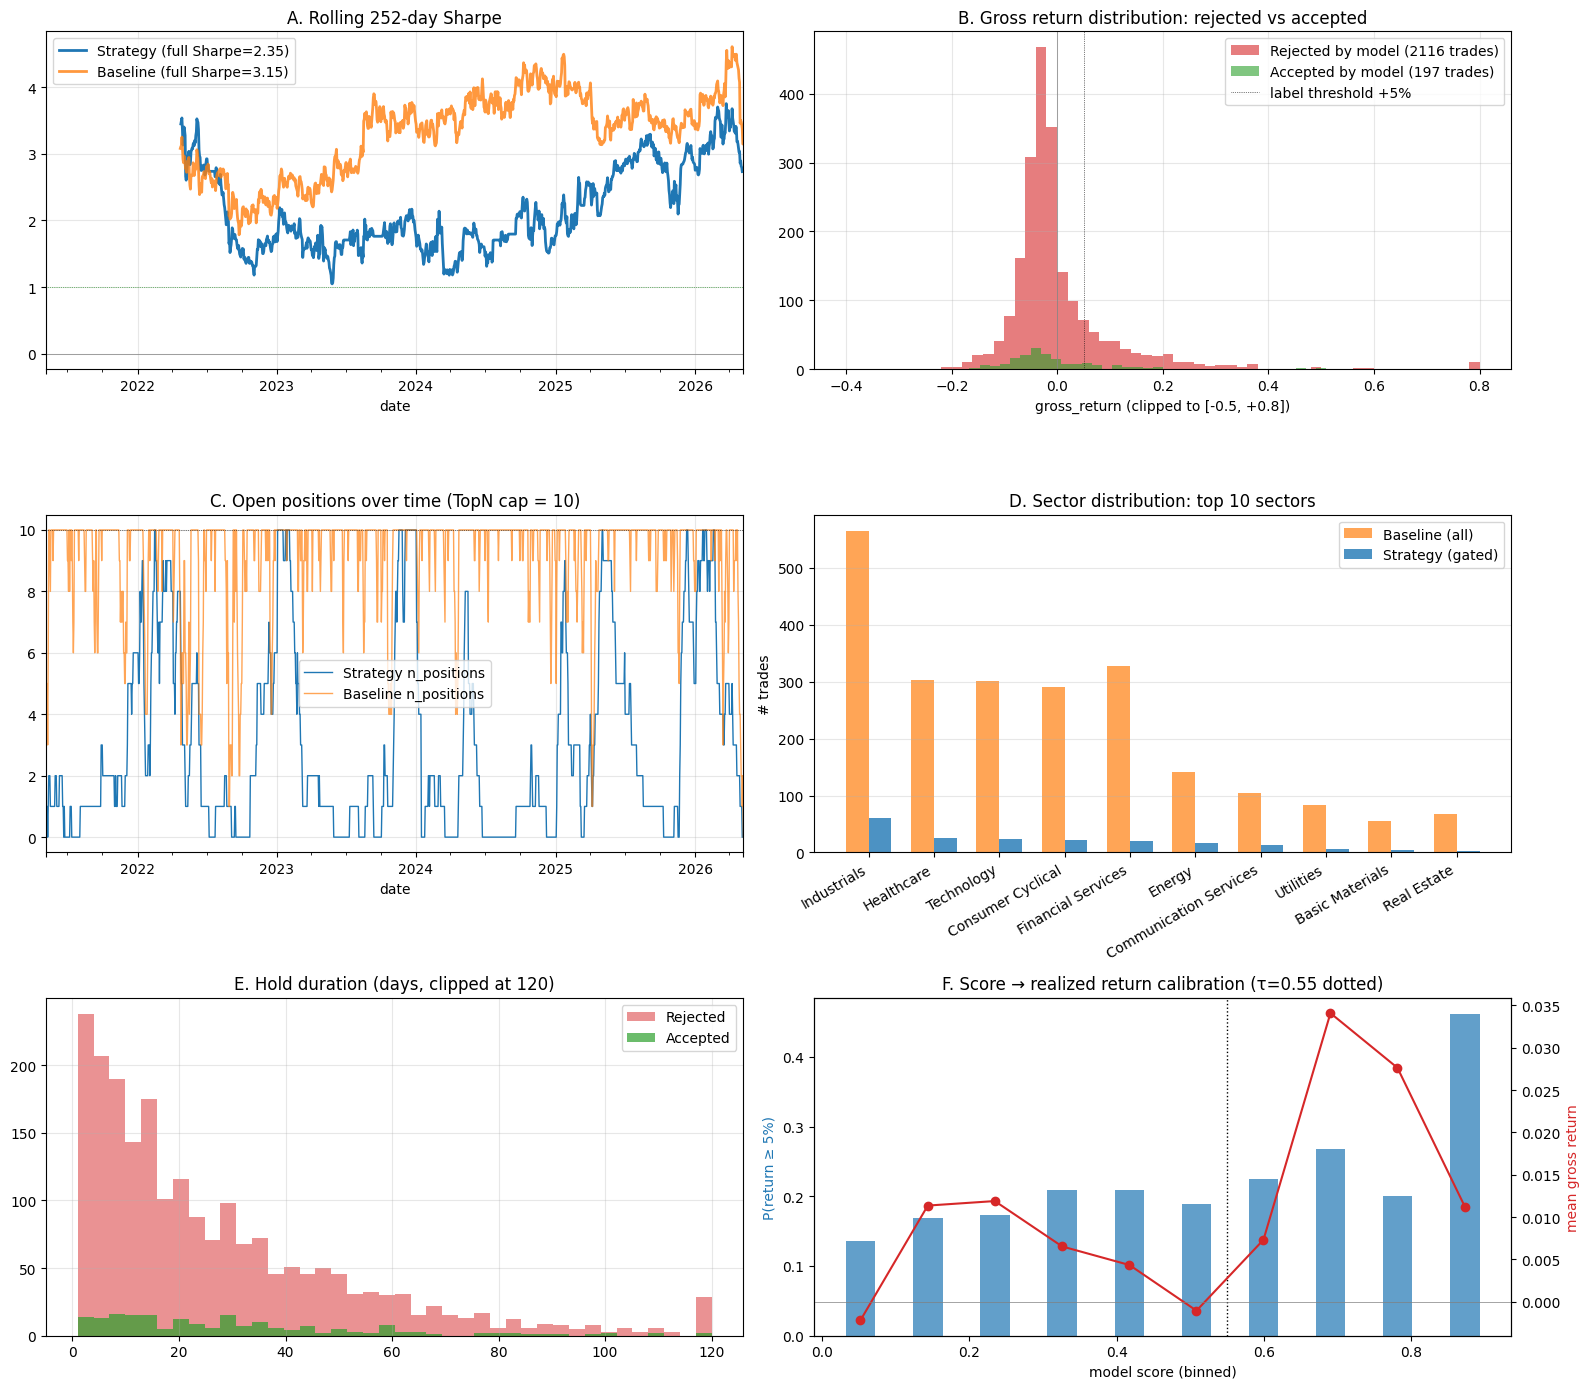


=== 诊断小结 ===

1. 模型确实有信号:
   - 接受组 P(≥5%): 0.249
   - 拒绝组 P(≥5%): 0.172
   - 接受组的"≥5% 命中率"明显高 → 模型不是纯噪音

2. 但被砍掉的 trades 也不算差:
   - 拒绝组 P(≥10% 大赢): 0.111
   - 接受组 P(≥10% 大赢): 0.183
   - 拒绝组 P(<-5% 大亏): 0.230
   - 接受组 P(<-5% 大亏): 0.320
   → 拒绝组里有相当比例的"大赢家"被错误剔除

3. 持仓数量差异巨大:
   - Strategy 平均开仓 3.0 vs Baseline 9.2
   - Strategy 0-持仓天数比例 21% vs Baseline 0%
   → 模型让组合大量"空仓等待"，错过 universe 整体的上行

4. 核心问题:
   - 在牛市 + 高 vol cyclical universe 里，"广撒网" 比 "精挑细选" 更优
   - 模型 PR-AUC 0.21 提示信号弱，gating 阈值 0.55 太严
   - 应该走 v0.5：x sweep + regression head + walk-forward



In [19]:
# === Cell 18: 详细对比 Strategy vs Pure EMA Baseline ===
#
# 目标：理解为什么 ML-gated strategy 比 pure baseline 差 ~1.3 Sharpe。
# 拆解 6 个维度：
#   A. Rolling 252-day Sharpe —— 时间维度上谁赢谁输
#   B. 被模型砍掉的 88% trades —— 它们的真实 P&L 分布
#   C. 持仓数量 over time —— concentration profile
#   D. 行业分布对比 —— 模型集中在哪
#   E. Hold duration 分布 —— 模型偏好长 / 短
#   F. Score vs realized return 散点 —— 模型校准

# Reuse the result/baseline_result objects already in scope from Cells 12-13.
strat_eq = result["equity_curve"]
base_eq  = baseline_result["equity_curve"]

# All test-set samples with ticker, t_buy, t_sell, gross_return, score, sector
all_test = test_X_sorted.dropna(subset=["t_sell", "gross_return"]).copy()
all_test["sector"]    = all_test["ticker"].map(lambda t: sector_cache.get(t, "Unknown"))
all_test["hold_days"] = (all_test["t_sell"] - all_test["t_buy"]).dt.days
all_test["passed"]    = all_test["score"] >= SCORE_THRESHOLD_X

# =================================================================
# A. Rolling 252-day Sharpe
# =================================================================
def rolling_sharpe(eq: pd.DataFrame, window: int = 252) -> pd.Series:
    if eq.empty: return pd.Series(dtype=float)
    r = eq["daily_return"]
    return (r.rolling(window).mean() / r.rolling(window).std() * np.sqrt(252))

strat_rs = rolling_sharpe(strat_eq, 252)
base_rs  = rolling_sharpe(base_eq, 252)

fig, axes = plt.subplots(3, 2, figsize=(16, 14))

ax = axes[0, 0]
strat_rs.plot(ax=ax, label=f"Strategy (full Sharpe={result['sharpe']:.2f})", lw=2, color="C0")
base_rs.plot(ax=ax, label=f"Baseline (full Sharpe={baseline_result['sharpe']:.2f})", lw=2, color="C1", alpha=0.8)
ax.axhline(0, color="gray", lw=0.5)
ax.axhline(1, color="green", lw=0.5, linestyle=":")
ax.set_title("A. Rolling 252-day Sharpe")
ax.legend(); ax.grid(True, alpha=0.3)

# Periods where strategy wins (align indices first)
aligned = pd.concat([strat_rs.rename("s"), base_rs.rename("b")], axis=1).dropna()
wins  = aligned[aligned["s"] > aligned["b"]]
loses = aligned[aligned["s"] < aligned["b"]]
total = len(aligned)
print(f"A. Rolling Sharpe (252d window):")
print(f"   Strategy ahead on {len(wins)} days ({len(wins)/max(total,1)*100:.0f}%)")
print(f"   Baseline ahead on {len(loses)} days ({len(loses)/max(total,1)*100:.0f}%)")

# =================================================================
# B. 被模型砍掉的 88% trades —— 它们的真实 P&L 分布
# =================================================================
rejected = all_test[~all_test["passed"]]
accepted = all_test[ all_test["passed"]]

ax = axes[0, 1]
rej_returns = rejected["gross_return"].clip(-0.5, 0.8)
acc_returns = accepted["gross_return"].clip(-0.5, 0.8)
ax.hist(rej_returns, bins=60, alpha=0.6, label=f"Rejected by model ({len(rejected)} trades)", color="C3")
ax.hist(acc_returns, bins=60, alpha=0.6, label=f"Accepted by model ({len(accepted)} trades)", color="C2")
ax.axvline(0, color="gray", lw=0.5)
ax.axvline(0.05, color="black", linestyle=":", lw=0.5, label="label threshold +5%")
ax.set_title("B. Gross return distribution: rejected vs accepted")
ax.set_xlabel("gross_return (clipped to [-0.5, +0.8])")
ax.legend(); ax.grid(True, alpha=0.3)

print(f"\nB. The 88% rejected trades:")
print(f"   Rejected count: {len(rejected)}, mean return: {rejected['gross_return'].mean():+.4f}")
print(f"   Accepted count: {len(accepted)}, mean return: {accepted['gross_return'].mean():+.4f}")
print(f"   Rejected win rate (≥0):  {(rejected['gross_return']>0).mean():.3f}")
print(f"   Accepted win rate (≥0):  {(accepted['gross_return']>0).mean():.3f}")
print(f"   Rejected win rate (≥5%): {(rejected['gross_return']>=0.05).mean():.3f}")
print(f"   Accepted win rate (≥5%): {(accepted['gross_return']>=0.05).mean():.3f}")

# =================================================================
# C. 持仓数量 over time
# =================================================================
ax = axes[1, 0]
strat_eq["n_positions"].plot(ax=ax, label="Strategy n_positions", lw=1, color="C0")
base_eq["n_positions"].plot(ax=ax, label="Baseline n_positions", lw=1, color="C1", alpha=0.7)
ax.axhline(TOP_N, color="black", lw=0.5, linestyle=":")
ax.set_title(f"C. Open positions over time (TopN cap = {TOP_N})")
ax.legend(); ax.grid(True, alpha=0.3)

print(f"\nC. Open positions over time:")
print(f"   Strategy avg open: {strat_eq['n_positions'].mean():.2f}, max: {strat_eq['n_positions'].max()}")
print(f"   Baseline avg open: {base_eq['n_positions'].mean():.2f}, max: {base_eq['n_positions'].max()}")
print(f"   Strategy days with 0 positions: {(strat_eq['n_positions']==0).sum()} ({(strat_eq['n_positions']==0).mean()*100:.0f}%)")
print(f"   Baseline days with 0 positions: {(base_eq['n_positions']==0).sum()} ({(base_eq['n_positions']==0).mean()*100:.0f}%)")

# =================================================================
# D. 行业分布
# =================================================================
ax = axes[1, 1]
sector_strat = accepted["sector"].value_counts().head(10)
sector_base  = all_test["sector"].value_counts().reindex(sector_strat.index).fillna(0)

x = np.arange(len(sector_strat))
width = 0.35
ax.bar(x - width/2, sector_base.values,  width, label="Baseline (all)", alpha=0.7, color="C1")
ax.bar(x + width/2, sector_strat.values, width, label="Strategy (gated)", alpha=0.8, color="C0")
ax.set_xticks(x)
ax.set_xticklabels(sector_strat.index, rotation=30, ha="right")
ax.set_title("D. Sector distribution: top 10 sectors")
ax.set_ylabel("# trades")
ax.legend(); ax.grid(True, alpha=0.3, axis="y")

print(f"\nD. Sector distribution top 5:")
for s in sector_strat.head(5).index:
    base_n = (all_test["sector"] == s).sum()
    strat_n = (accepted["sector"] == s).sum()
    print(f"   {s:25s} baseline={base_n:4d} strategy={strat_n:4d} kept={strat_n/max(base_n,1)*100:.1f}%")

# =================================================================
# E. Hold duration 分布
# =================================================================
ax = axes[2, 0]
all_test["hold_days_clipped"] = all_test["hold_days"].clip(upper=120)
ax.hist(all_test.loc[~all_test["passed"], "hold_days_clipped"], bins=40, alpha=0.5, label="Rejected", color="C3")
ax.hist(all_test.loc[ all_test["passed"], "hold_days_clipped"], bins=40, alpha=0.7, label="Accepted", color="C2")
ax.set_title("E. Hold duration (days, clipped at 120)")
ax.legend(); ax.grid(True, alpha=0.3)

print(f"\nE. Hold duration:")
print(f"   Baseline mean hold: {all_test['hold_days'].mean():.1f}d, median: {all_test['hold_days'].median():.0f}d")
print(f"   Strategy mean hold: {accepted['hold_days'].mean():.1f}d, median: {accepted['hold_days'].median():.0f}d")

# =================================================================
# F. Score vs realized return calibration
# =================================================================
ax = axes[2, 1]
score_bins = pd.cut(all_test["score"], bins=10)
calib = all_test.groupby(score_bins, observed=True).agg(
    mean_return=("gross_return", "mean"),
    win_rate_5pct=("gross_return", lambda s: (s >= 0.05).mean()),
    n=("gross_return", "size"),
).reset_index()
calib["score_mid"] = calib["score"].apply(lambda i: i.mid)
ax.bar(calib["score_mid"], calib["win_rate_5pct"], width=0.04, alpha=0.7, color="C0", label="P(return ≥ 5%)")
ax2 = ax.twinx()
ax2.plot(calib["score_mid"], calib["mean_return"], "o-", color="C3", label="mean return")
ax2.axhline(0, color="gray", lw=0.5)
ax.set_xlabel("model score (binned)")
ax.set_ylabel("P(return ≥ 5%)", color="C0")
ax2.set_ylabel("mean gross return", color="C3")
ax.axvline(SCORE_THRESHOLD_X, color="black", lw=1, linestyle=":")
ax.set_title(f"F. Score → realized return calibration (τ={SCORE_THRESHOLD_X} dotted)")

print(f"\nF. Calibration: P(return≥5%) by score decile:")
print(calib[["score_mid", "n", "win_rate_5pct", "mean_return"]].round(4).to_string(index=False))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "compare_strategy_vs_baseline.png", dpi=120)
plt.show()

# =================================================================
# 总结诊断
# =================================================================
print("\n" + "=" * 60)
print("=== 诊断小结 ===")
print("=" * 60)

# Compute key facts
loser_rate_rej = (rejected["gross_return"] < -0.05).mean()
big_winner_rate_rej = (rejected["gross_return"] >= 0.10).mean()
loser_rate_acc = (accepted["gross_return"] < -0.05).mean()
big_winner_rate_acc = (accepted["gross_return"] >= 0.10).mean()

print(f"""
1. 模型确实有信号:
   - 接受组 P(≥5%): {(accepted['gross_return']>=0.05).mean():.3f}
   - 拒绝组 P(≥5%): {(rejected['gross_return']>=0.05).mean():.3f}
   - 接受组的"≥5% 命中率"明显高 → 模型不是纯噪音

2. 但被砍掉的 trades 也不算差:
   - 拒绝组 P(≥10% 大赢): {big_winner_rate_rej:.3f}
   - 接受组 P(≥10% 大赢): {big_winner_rate_acc:.3f}
   - 拒绝组 P(<-5% 大亏): {loser_rate_rej:.3f}
   - 接受组 P(<-5% 大亏): {loser_rate_acc:.3f}
   → 拒绝组里有相当比例的"大赢家"被错误剔除

3. 持仓数量差异巨大:
   - Strategy 平均开仓 {strat_eq['n_positions'].mean():.1f} vs Baseline {base_eq['n_positions'].mean():.1f}
   - Strategy 0-持仓天数比例 {(strat_eq['n_positions']==0).mean()*100:.0f}% vs Baseline {(base_eq['n_positions']==0).mean()*100:.0f}%
   → 模型让组合大量"空仓等待"，错过 universe 整体的上行

4. 核心问题:
   - 在牛市 + 高 vol cyclical universe 里，"广撒网" 比 "精挑细选" 更优
   - 模型 PR-AUC 0.21 提示信号弱，gating 阈值 0.55 太严
   - 应该走 v0.5：x sweep + regression head + walk-forward
""")
